## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import pandas as pd

from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import classification_report, accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import PowerTransformer, RobustScaler, QuantileTransformer, StandardScaler
from sklearn.svm import SVC

from scipy import stats
from scipy.stats import mstats

import pydotplus
from graphviz import Source
from IPython.display import Image, display

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

import os
import math
from itertools import product
from typing import List, Tuple, Dict, Optional, Iterable
import joblib

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# Defining colors and labels for use in visualizations

In [2]:
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Shirt'}
colors = {0: 'red', 1: 'blue', 2: 'yellow', 3: 'green', 4: 'purple'}
light_colors = {0: '#ffcccc', 1: '#ccccff', 2: '#ffffcc', 3: '#ccffcc', 4: '#e5ccff'}

# Load/Prepare data set

In [3]:
# Load data from the correct location using relative paths
train_data = np.load('raw_data/fashion_train.npy')
test_data = np.load('raw_data/fashion_test.npy')

print(train_data.shape)
print(test_data.shape)
print(test_data)


(10000, 785)
(5000, 785)
[[0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 3]
 ...
 [0 0 0 ... 0 0 4]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 2]]


# Seperating labels from data

In [4]:
# Extract labels from data
train_labels = train_data[:, -1]
test_labels = test_data[:, -1]
print(train_labels.shape)
print(test_labels.shape)

# Save the labels to the Modified_Datasets folder
np.save('Modified_Datasets/train_labels.npy', train_labels)
np.save('Modified_Datasets/test_labels.npy', test_labels)

# Dropping labels from data
train_data = train_data[:, :-1]
test_data = test_data[:, :-1]
print(train_data.shape)
print(test_data.shape)


(10000,)
(5000,)
(10000, 784)
(5000, 784)


#NaN value check

In [5]:
print(f"NaN values in train_data: {np.isnan(train_data).sum()}")
print(f"NaN values in test_data: {np.isnan(test_data).sum()}")

NaN values in train_data: 0
NaN values in test_data: 0


### EDB

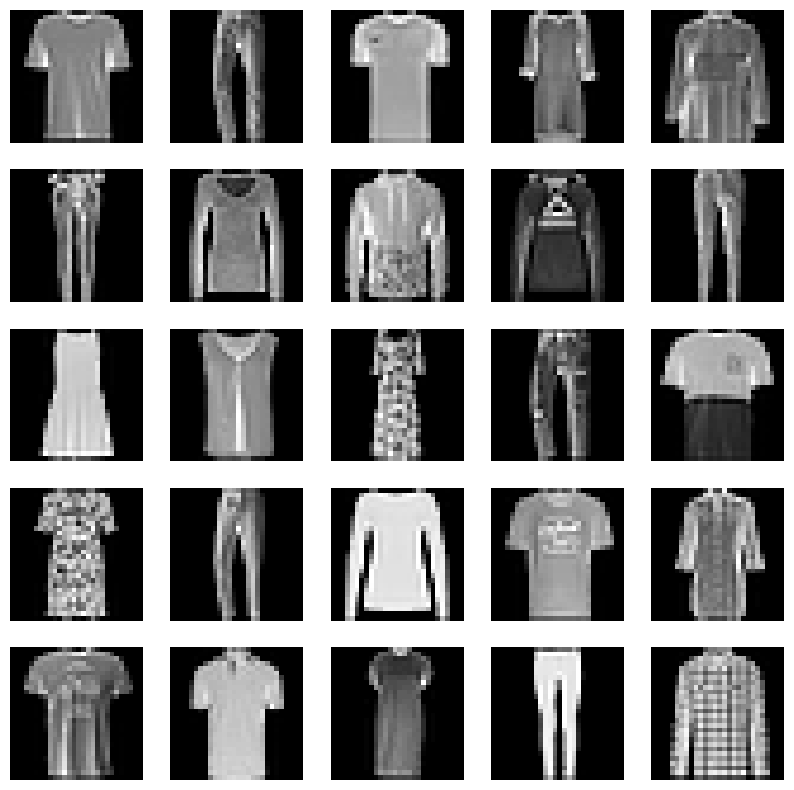

In [6]:
# Reshape the data to 28x28 images
train_gray = train_data.reshape(-1, 28, 28)
test_gray = test_data.reshape(-1, 28, 28)

# Save the reshaped data to the Modified_Datasets folder
np.save('Modified_Datasets/train_gray.npy', train_gray)
np.save('Modified_Datasets/test_gray.npy', test_gray)

# Create and save the plot
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(train_gray[i], cmap='gray')
    plt.axis('off')
plt.savefig('Images/train_gray_plot.png')
plt.show()


In [7]:
# Count the occurrences of each label
unique, counts = np.unique(train_labels, return_counts=True)

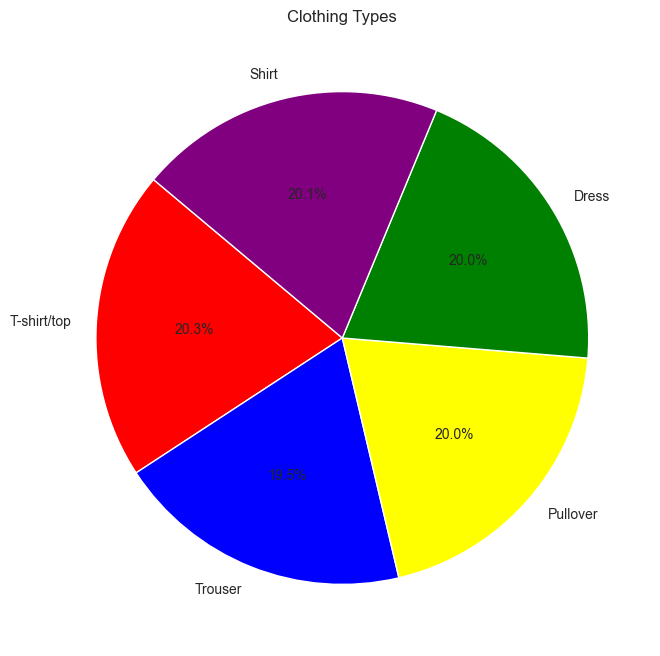

This pie chart shows that we have a nearly equally balanced dataset, meaning that the risk of bias is reduced.


In [8]:
# Map the colors and label names to the unique labels
pie_colors = [colors[label] for label in unique]
pie_labels = [labels[label] for label in unique]

# Create and save a pie chart of normalized pixel values for each category
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=pie_labels, colors=pie_colors, autopct='%1.1f%%', startangle=140)
plt.title('Clothing Types')
plt.savefig('Images/clothing_types_pie_chart.png')
plt.show()

print("This pie chart shows that we have a nearly equally balanced dataset, meaning that the risk of bias is reduced.")


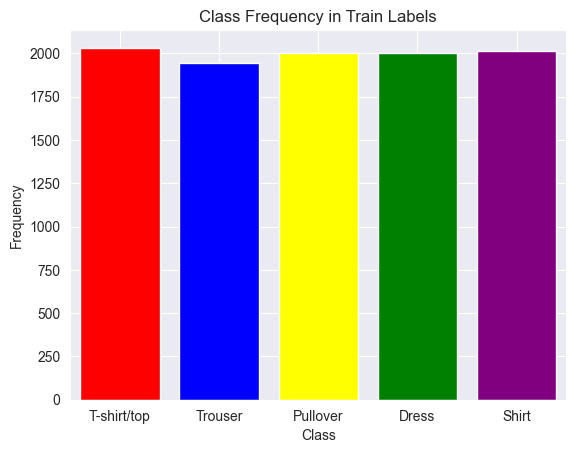

In [9]:
# Get unique classes and their counts
unique_classes, class_counts = np.unique(train_labels, return_counts=True)

# Create and save a bar plot
plt.bar(unique_classes, class_counts, color=[colors[cls] for cls in unique_classes])
plt.xticks(unique_classes, [labels[cls] for cls in unique_classes])  # set the x-ticks to the unique classes

# Set the x-axis limits to show all unique classes
plt.xlim(unique_classes[0] - 0.5, unique_classes[-1] + 0.5)

plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Class Frequency in Train Labels')

plt.savefig('Images/class_frequency_bar_chart.png')
plt.show()


In [10]:
# Function to calculate the number of bins using Scott's rule
def scott_bins(data):
    std_dev = np.std(data)
    bin_width = 3.5 * std_dev * len(data) ** (-1/3)
    bins = int((data.max() - data.min()) / bin_width)
    return bins

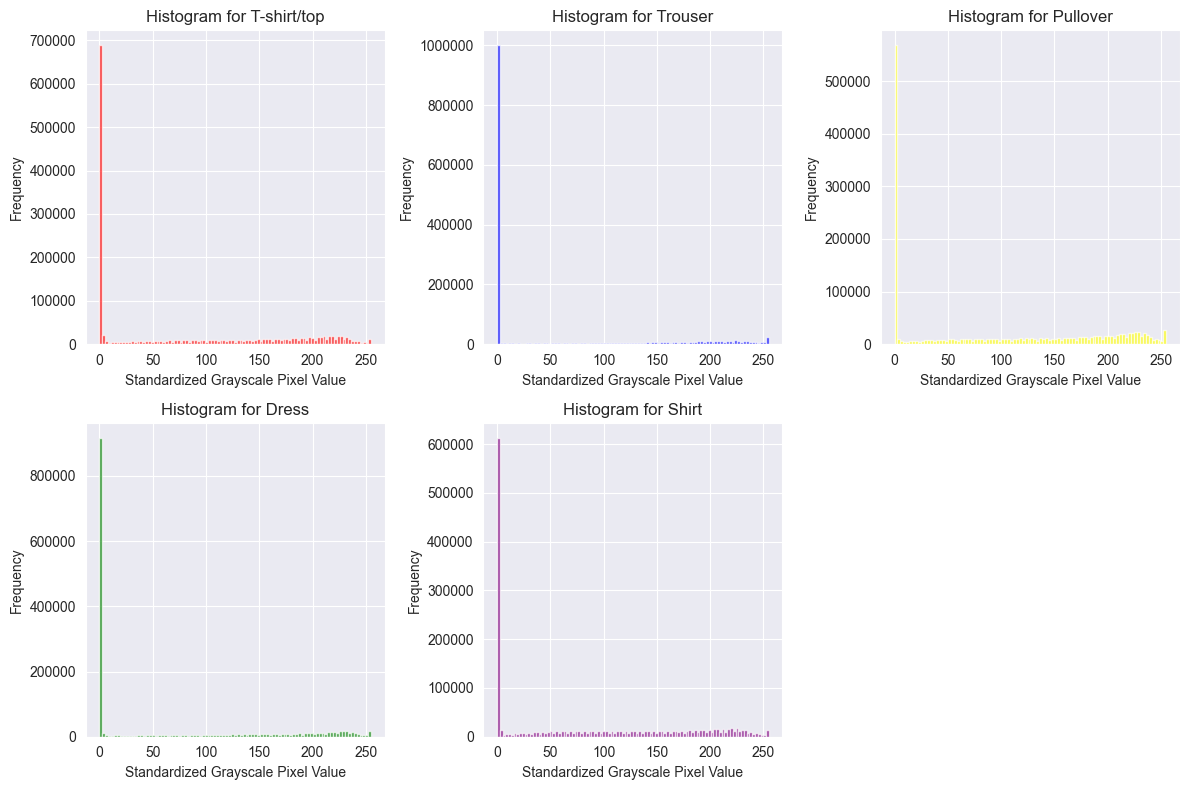

In [11]:
# Create a single chart with multiple histograms and limited axes
plt.figure(figsize=(12, 8))

for i, label in enumerate(np.unique(train_labels)):
    plt.subplot(2, 3, i + 1)
    data = train_gray[train_labels == label].flatten()
    bins = scott_bins(data)
    plt.hist(data, bins=bins, color=colors[label], alpha=0.7)
    plt.title(f'Histogram for {labels[label]}')
    plt.xlabel('Standardized Grayscale Pixel Value')
    plt.ylabel('Frequency')
    plt.ticklabel_format(style='plain', axis='y')  # Display y-axis in plain format

plt.tight_layout()
plt.savefig('Images/multiple_histograms.png')
plt.show()


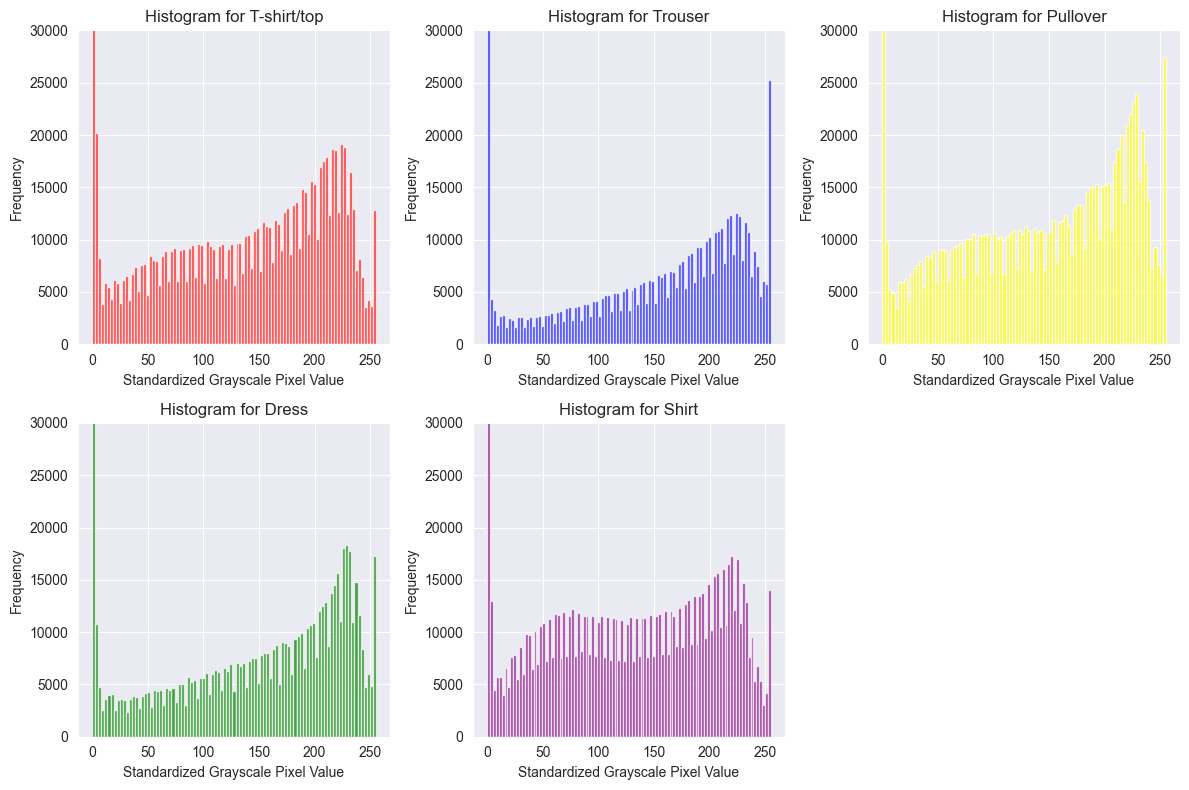

The y limits have been changed to improve readability


In [12]:
# Create a single chart with multiple histograms and limited axes
plt.figure(figsize=(12, 8))

for i, label in enumerate(np.unique(train_labels)):
    plt.subplot(2, 3, i + 1)
    data = train_gray[train_labels == label].flatten()
    bins = scott_bins(data)
    plt.hist(data, bins=bins, color=colors[label], alpha=0.7)
    plt.title(f'Histogram for {labels[label]}')
    plt.xlabel('Standardized Grayscale Pixel Value')
    plt.ylabel('Frequency')
    plt.ylim(None, 30000)
    plt.ticklabel_format(style='plain', axis='y')  # Display y-axis in plain format

plt.tight_layout()
plt.savefig('Images/truncated_histograms.png')
plt.show()

print("The y limits have been changed to improve readability")


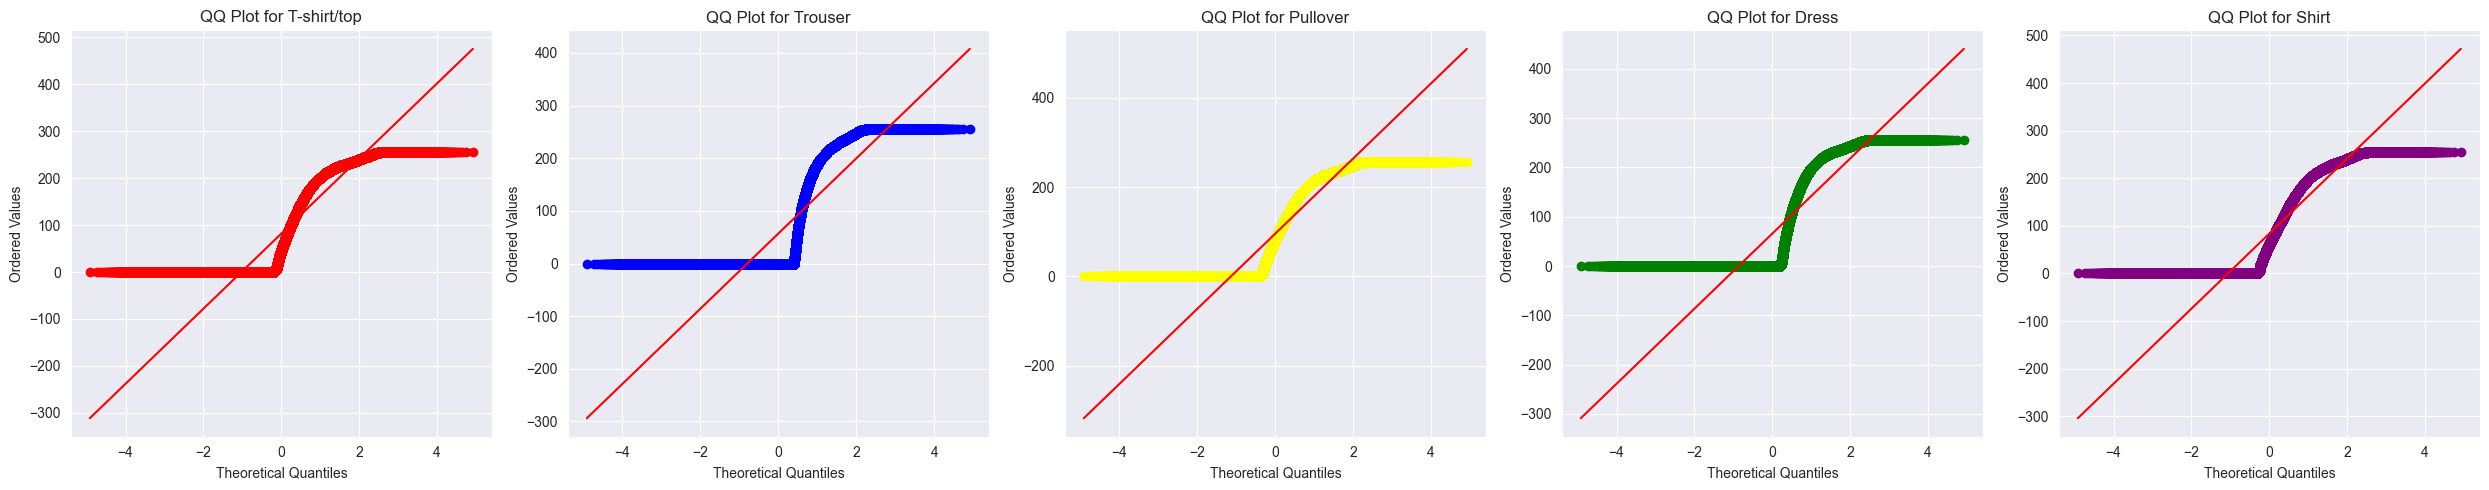

This data is obviously not linear based on the QQ Plots for each category.
It makes sense to use machine learning methods for higher dimensional data rather than attempt to force the data into a normal distribution.


In [28]:
# Create a single chart with multiple QQ plots
plt.figure(figsize=(25,5))

for i, label in enumerate(np.unique(train_labels)):
    plt.subplot(1, 5, i + 1)
    data = train_gray[train_labels == label].flatten()
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    plt.plot(osm, osr, 'o', color=colors[label])  # Color the points
    plt.plot(osm, slope * osm + intercept, 'r')  # Red line
    plt.title(f'QQ Plot for {labels[label]}')
    plt.xlabel('Theoretical Quantiles')
    plt.ylabel('Ordered Values')
    plt.grid(True)

plt.tight_layout()
plt.savefig('Images/qq_plots.png')
plt.show()

print("This data is obviously not linear based on the QQ Plots for each category.\n"
      "It makes sense to use machine learning methods for higher dimensional data rather than attempt to force the data into a normal distribution.")


C:\Users\edbma\AppData\Local\Temp\ipykernel_18816\1237128368.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Mean Pixel Value', data=df, palette=[colors[cls] for cls in labels.keys()])


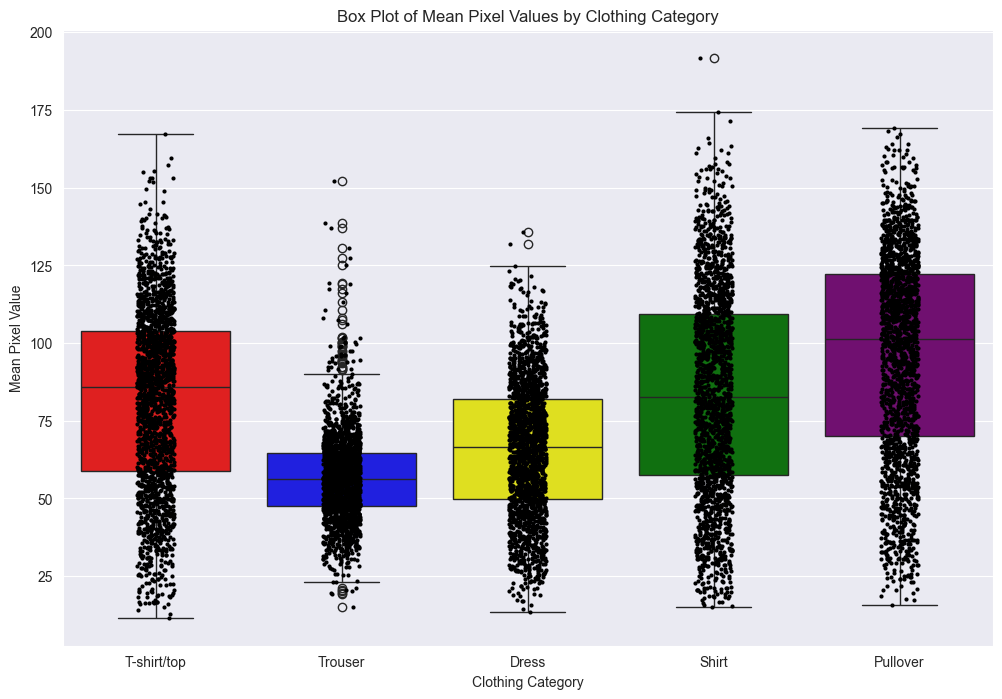

In [26]:
# Create a DataFrame for Seaborn
df = pd.DataFrame({'Category': train_labels, 'Mean Pixel Value': train_gray.mean(axis=(1, 2))})

# Map the label names to the unique labels
df['Category'] = df['Category'].map(labels)

# Create and save a box plot with Seaborn
plt.figure(figsize=(12, 8))
sns.boxplot(x='Category', y='Mean Pixel Value', data=df, palette=[colors[cls] for cls in labels.keys()])

# Add points for individual data points using stripplot
sns.stripplot(x='Category', y='Mean Pixel Value', data=df, color='black', size=3, jitter=True)

# Save and show the plot
plt.title('Box Plot of Mean Pixel Values by Clothing Category')
plt.xlabel('Clothing Category')
plt.ylabel('Mean Pixel Value')
plt.savefig('Images/box_plot_mean_pixel_values.png')
plt.show()


In [15]:
# Print the five-number summaries for each category
summary = df.groupby('Category')['Mean Pixel Value'].describe(percentiles=[.25, .5, .75])
five_number_summary = summary[['min', '25%', '50%', '75%', 'max']]

# Save the report to the Reports folder
five_number_summary.to_csv('Reports/five_number_summaries.csv')

# Add the title and print the report
print("Five Number Summaries")
print(five_number_summary)


Five Number Summaries
                   min        25%         50%         75%         max
Category                                                             
Dress        13.461735  49.937500   66.385204   81.826531  135.692602
Pullover     15.589286  70.135204  101.422194  122.146684  169.139031
Shirt        14.975765  57.528061   82.637755  109.230230  191.820153
T-shirt/top  11.581633  58.891582   85.875000  103.714286  167.192602
Trouser      15.128827  47.543367   56.349490   64.679847  152.278061


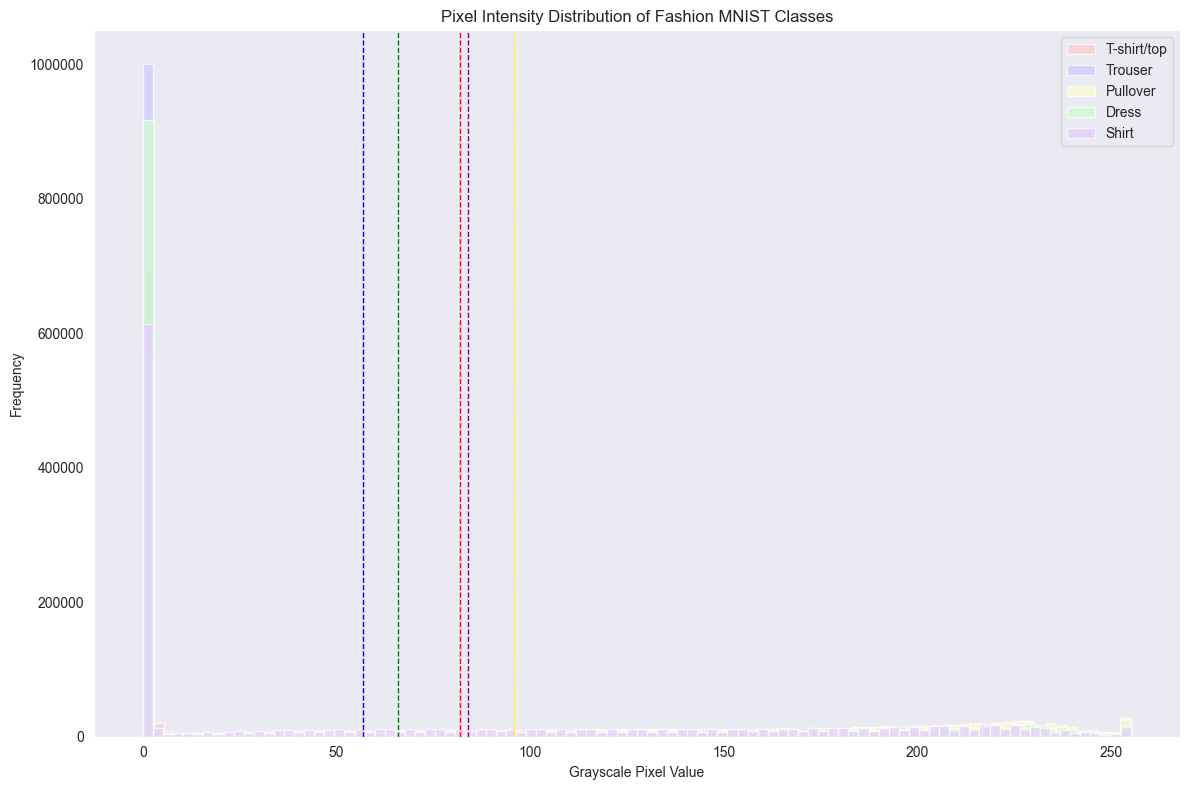

In [24]:
# Assuming 'labels', 'colors', and 'light_colors' are already defined
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Shirt'}
colors = {0: 'red', 1: 'blue', 2: 'yellow', 3: 'green', 4: 'purple'}
light_colors = {0: '#ffcccc', 1: '#ccccff', 2: '#ffffcc', 3: '#ccffcc', 4: '#e5ccff'}

# Create a single chart with multiple histograms and limited axes
plt.figure(figsize=(12, 8), facecolor='white')

# T-shirt/top
data = train_gray[train_labels == 0].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[0], alpha=0.7, label=labels[0])
plt.axvline(np.mean(data), color=colors[0], linestyle='dashed', linewidth=1)

# Trouser
data = train_gray[train_labels == 1].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[1], alpha=0.7, label=labels[1])
plt.axvline(np.mean(data), color=colors[1], linestyle='dashed', linewidth=1)

# Pullover
data = train_gray[train_labels == 2].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[2], alpha=0.7, label=labels[2])
plt.axvline(np.mean(data), color=colors[2], linestyle='dashed', linewidth=1)

# Dress
data = train_gray[train_labels == 3].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[3], alpha=0.7, label=labels[3])
plt.axvline(np.mean(data), color=colors[3], linestyle='dashed', linewidth=1)

# Shirt
data = train_gray[train_labels == 4].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[4], alpha=0.7, label=labels[4])
plt.axvline(np.mean(data), color=colors[4], linestyle='dashed', linewidth=1)

plt.legend()
plt.xlabel('Grayscale Pixel Value')
plt.ylabel('Frequency')
plt.grid(False)

plt.title('Pixel Intensity Distribution of Fashion MNIST Classes')
plt.ticklabel_format(style='plain', axis='y')  # Display y-axis in plain format
plt.tight_layout()
plt.savefig('Images/pixel_intensity_distribution.png')
plt.show()


Normalizing and standardizing the data to a mean of 0 and standard deviation of 1.

In [17]:
epsilon = 1e-8  # Small constant to avoid division by zero

# Normalizing the data
train_data_norm = (train_data - np.mean(train_data, axis=0)) / (np.std(train_data, axis=0) + epsilon)
test_data_norm = (test_data - np.mean(test_data, axis=0)) / (np.std(test_data, axis=0) + epsilon)

# Save the normalized data to the Modified_Datasets folder
np.save('Modified_Datasets/train_data_norm.npy', train_data_norm)
np.save('Modified_Datasets/test_data_norm.npy', test_data_norm)


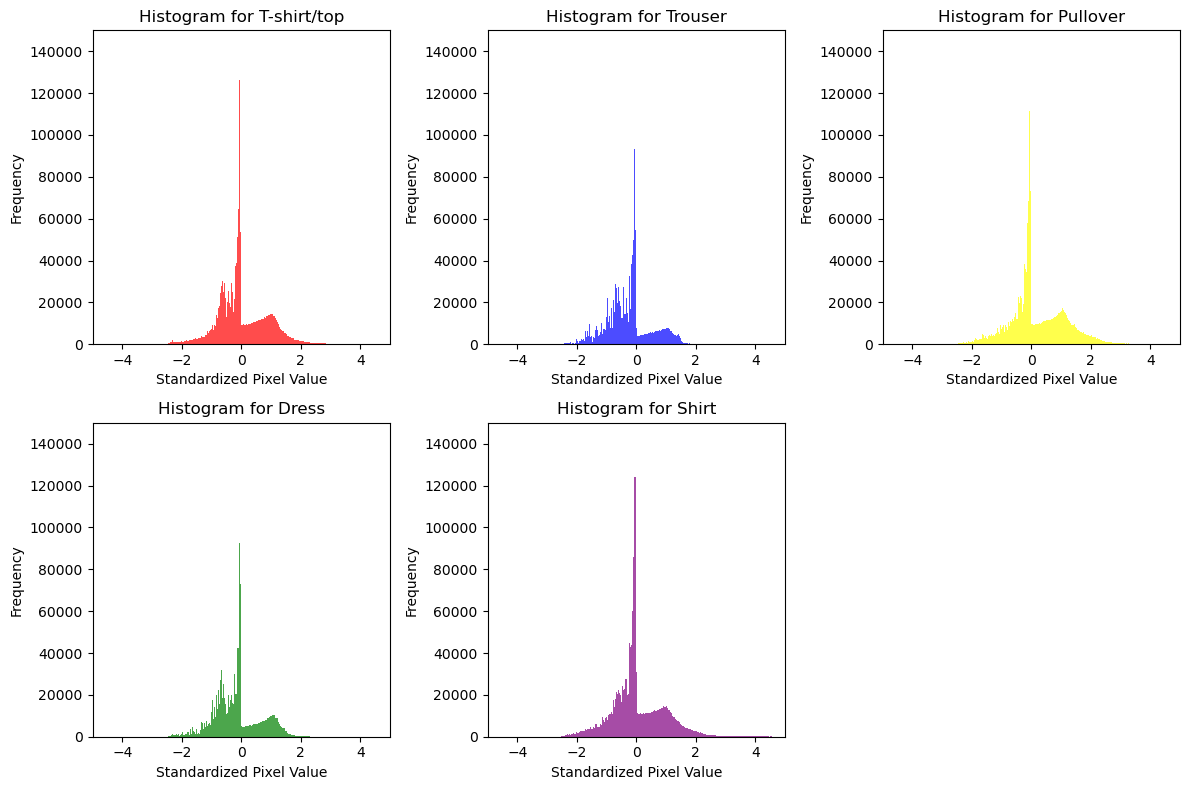

In [18]:
# Create a single chart with multiple histograms and limited axes
plt.figure(figsize=(12, 8))

for i, label in enumerate(np.unique(train_labels)):
    plt.subplot(2, 3, i + 1)
    data = train_data_norm[train_labels == label].flatten()
    bins = scott_bins(data)
    plt.hist(data, bins=bins, color=colors[label], alpha=0.7)
    plt.title(f'Histogram for {labels[label]}')
    plt.xlabel('Standardized Pixel Value')
    plt.ylabel('Frequency')
    plt.xlim(-5, 5)
    plt.ylim(0, 150000)
    plt.ticklabel_format(style='plain', axis='y')  # Display y-axis in plain format

plt.tight_layout()
plt.savefig('Images/standardized_histograms.png')
plt.show()


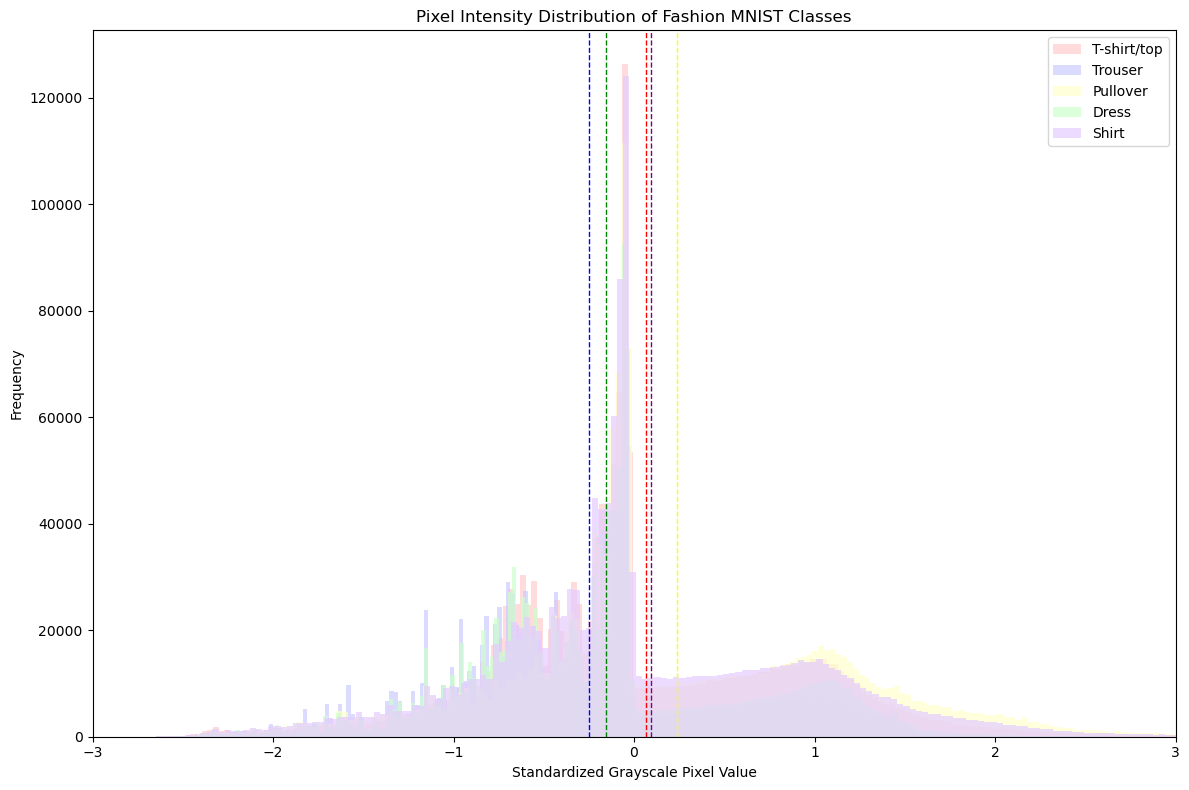

There is a lot of overlap between classes.
Methods for higher dimensionality data such as support vector machines, Neural Networks and Decision Trees would be beneficial.


In [19]:
# Create a single chart with multiple histograms and limited axes
plt.figure(figsize=(12, 8))

# T-shirt/top
data = train_data_norm[train_labels == 0].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[0], alpha=0.7, label=labels[0])
plt.axvline(np.mean(data), color=colors[0], linestyle='dashed', linewidth=1)

# Trouser
data = train_data_norm[train_labels == 1].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[1], alpha=0.7, label=labels[1])
plt.axvline(np.mean(data), color=colors[1], linestyle='dashed', linewidth=1)

# Pullover
data = train_data_norm[train_labels == 2].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[2], alpha=0.7, label=labels[2])
plt.axvline(np.mean(data), color=colors[2], linestyle='dashed', linewidth=1)

# Dress
data = train_data_norm[train_labels == 3].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[3], alpha=0.7, label=labels[3])
plt.axvline(np.mean(data), color=colors[3], linestyle='dashed', linewidth=1)

# Shirt
data = train_data_norm[train_labels == 4].flatten()
bins = scott_bins(data)
plt.hist(data, bins=bins, color=light_colors[4], alpha=0.7, label=labels[4])
plt.axvline(np.mean(data), color=colors[4], linestyle='dashed', linewidth=1)

plt.legend()
plt.xlabel('Standardized Grayscale Pixel Value')
plt.ylabel('Frequency')
plt.xlim(-3, 3)
plt.title('Pixel Intensity Distribution of Fashion MNIST Classes')
plt.ticklabel_format(style='plain', axis='y')  # Display y-axis in plain format
plt.tight_layout()
plt.savefig('Images/standardized_pixel_intensity.png')
plt.show()

print("There is a lot of overlap between classes.\n"
      "Methods for higher dimensionality data such as support vector machines, Neural Networks and Decision Trees would be beneficial.")


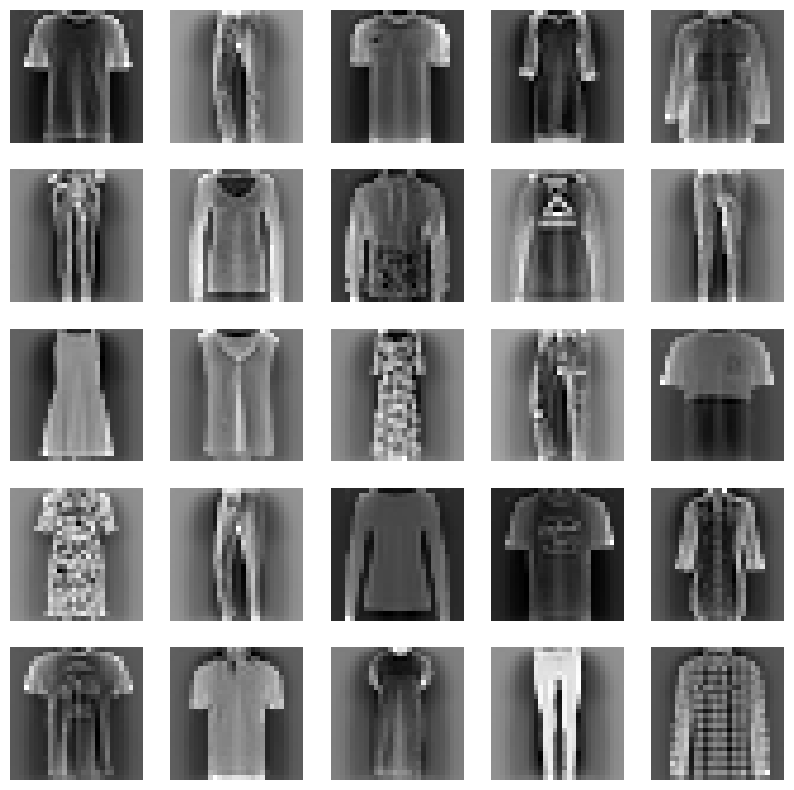

In [20]:
# Reshape the data to 28x28 images
train_norm_gray = train_data_norm.reshape(-1, 28, 28)
test_norm_gray = train_data_norm.reshape(-1, 28, 28)

# Save the reshaped data to the Modified_Datasets folder
np.save('Modified_Datasets/train_norm_gray.npy', train_norm_gray)
np.save('Modified_Datasets/test_norm_gray.npy', test_norm_gray)

# Create and save the plot
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(train_norm_gray[i], cmap='gray')
    plt.axis('off')
plt.savefig('Images/normalized_grayscale.png')
plt.show()


# Dimensionality Reduction

**PCA** -- Preserves as much variability as possible

In [21]:
# Define the number of components to keep
n_components = 4

# Make PCA model
pca = PCA(n_components=n_components)

# Fit PCA on the training data and transform both training and test data
train_data_pca = pca.fit_transform(train_data_norm)
test_data_pca = pca.transform(test_data_norm)

# Save the PCA-transformed data to the Modified_Datasets folder
np.save('Modified_Datasets/train_data_pca.npy', train_data_pca)
np.save('Modified_Datasets/test_data_pca.npy', test_data_pca)

print(f"Original shape: {test_data_norm.shape}")
print(f"Transformed shape: {train_data_pca.shape}")


Original shape: (5000, 784)
Transformed shape: (10000, 4)


In [22]:
# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance by the first four principal components: {explained_variance_ratio}")
# Calculate the total variance explained by the first two principal components
total_explained_variance = np.sum(explained_variance_ratio)
print(f"Total variance explained by the first four principal components: {total_explained_variance * 100:.2f}%")

Explained variance by the first four principal components: [0.22645698 0.13673557 0.06381166 0.05046707]
Total variance explained by the first four principal components: 47.75%


In [23]:
def plot_pca(data, data_labels, title):
    plt.figure(figsize=(10, 7))
    for label in np.unique(data_labels):
        indices = data_labels == label
        plt.scatter(data[indices, 0], data[indices, 1], color=colors[label], label=labels[label], alpha=0.5)
    plt.legend()
    plt.title(title)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.savefig('Images/pca_plot.png')
    plt.show()


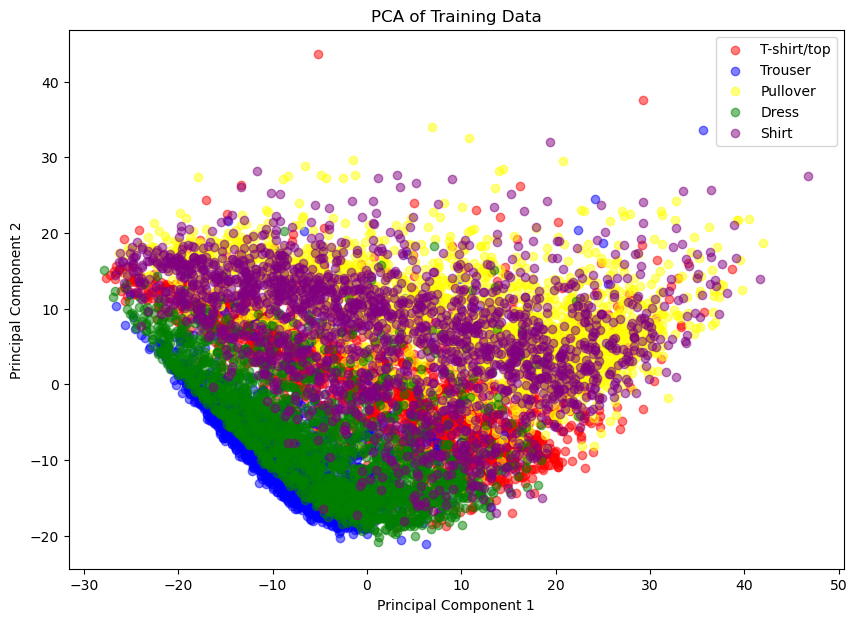

In [24]:
# Plotting the PCA results for the training data
plot_pca(train_data_pca, train_labels, 'PCA of Training Data')

**LDA** -- Preserves as much seperation between classes as possible

In [25]:
# Initialize LDA
lda = LinearDiscriminantAnalysis(n_components=4)

# Fit LDA on the training data and transform both training and test data
train_data_lda = lda.fit_transform(train_data_norm, train_labels)
test_data_lda = lda.transform(test_data_norm)

# Save the LDA-transformed data to the Modified_Datasets folder
np.save('Modified_Datasets/train_data_lda.npy', train_data_lda)
np.save('Modified_Datasets/test_data_lda.npy', test_data_lda)

print(f"Original shape: {train_data_norm.shape}")
print(f"Transformed shape: {train_data_lda.shape}")


Original shape: (10000, 784)
Transformed shape: (10000, 4)


In [26]:
# Calculate the explained variance ratio
explained_variance_ratio_lda = lda.explained_variance_ratio_
print(f"Explained variance by the first four linear discriminants: {explained_variance_ratio_lda}")
# Calculate the total variance explained by the first four linear discriminants
total_explained_variance_lda = np.sum(explained_variance_ratio_lda)
print(f"Total variance explained by the first four linear discriminants: {total_explained_variance_lda * 100:.2f}%")

Explained variance by the first four linear discriminants: [0.61113178 0.20240552 0.13128745 0.05517525]
Total variance explained by the first four linear discriminants: 100.00%


In [27]:
def plot_lda(data, data_labels, title):
    plt.figure(figsize=(10, 7))
    for label in np.unique(data_labels):
        indices = data_labels == label
        plt.scatter(data[indices, 0], data[indices, 1], color=colors[label], label=labels[label], alpha=0.5)
    plt.legend()
    plt.title(title)
    plt.xlabel('Linear Discriminant 1')
    plt.ylabel('Linear Discriminant 2')
    plt.savefig('Images/lda_plot.png')
    plt.show()


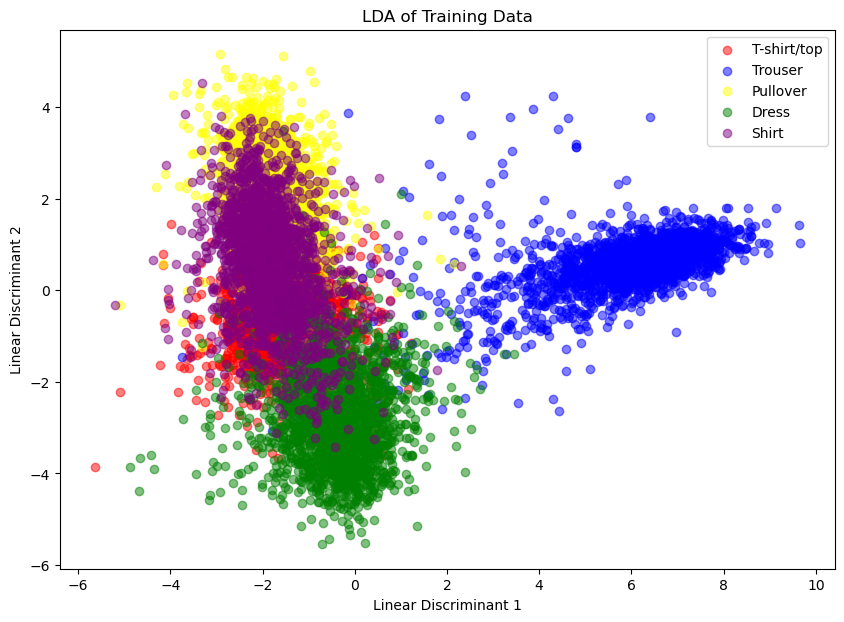

In [28]:
# Plotting the LDA results for the training data
plot_lda(train_data_lda, train_labels, 'LDA of Training Data')

# Reference Decision Tree

**With PCA**

In [95]:
# Initialize the decision tree classifier with max_depth=5
clf = DecisionTreeClassifier(max_depth=5)

# Fit the model on the training data
clf.fit(train_data_pca, train_labels)

# Save the trained model to the trained_models folder
import joblib
joblib.dump(clf, 'trained_models/reference_decision_tree_pca_model.pkl')

# Make predictions on the test data
test_predictions = clf.predict(test_data_pca)

# Save the predictions to the Predictions folder
np.save('Predictions/reference_decision_tree_pca_predictions.npy', test_predictions)


In [96]:
# Generate the classification report with label names
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
report_pca = classification_report(test_labels, test_predictions, target_names=label_names)

# Save the report to the Reports folder
with open('Reports/Report_Reference_Decision_Tree_with_PCA.txt', 'w') as f:
    f.write("Reference Decision Tree Trained on PCA\n")
    f.write(report_pca)

# Add the title and print the report
print("Report Reference Decision Tree with PCA")
print(report_pca)


Report Reference Decision Tree with PCA
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.74      0.74      1000
     Trouser       0.92      0.68      0.78      1000
    Pullover       0.61      0.83      0.70      1000
       Dress       0.61      0.82      0.70      1000
       Shirt       0.39      0.21      0.28      1000

    accuracy                           0.66      5000
   macro avg       0.65      0.66      0.64      5000
weighted avg       0.65      0.66      0.64      5000



In [97]:
# Calculate accuracy
accuracy_pca = np.mean(test_predictions == test_labels)
print(f"Reference Decision Tree Accuracy with PCA: {accuracy_pca * 100:.2f}%")

Reference Decision Tree Accuracy with PCA: 65.58%


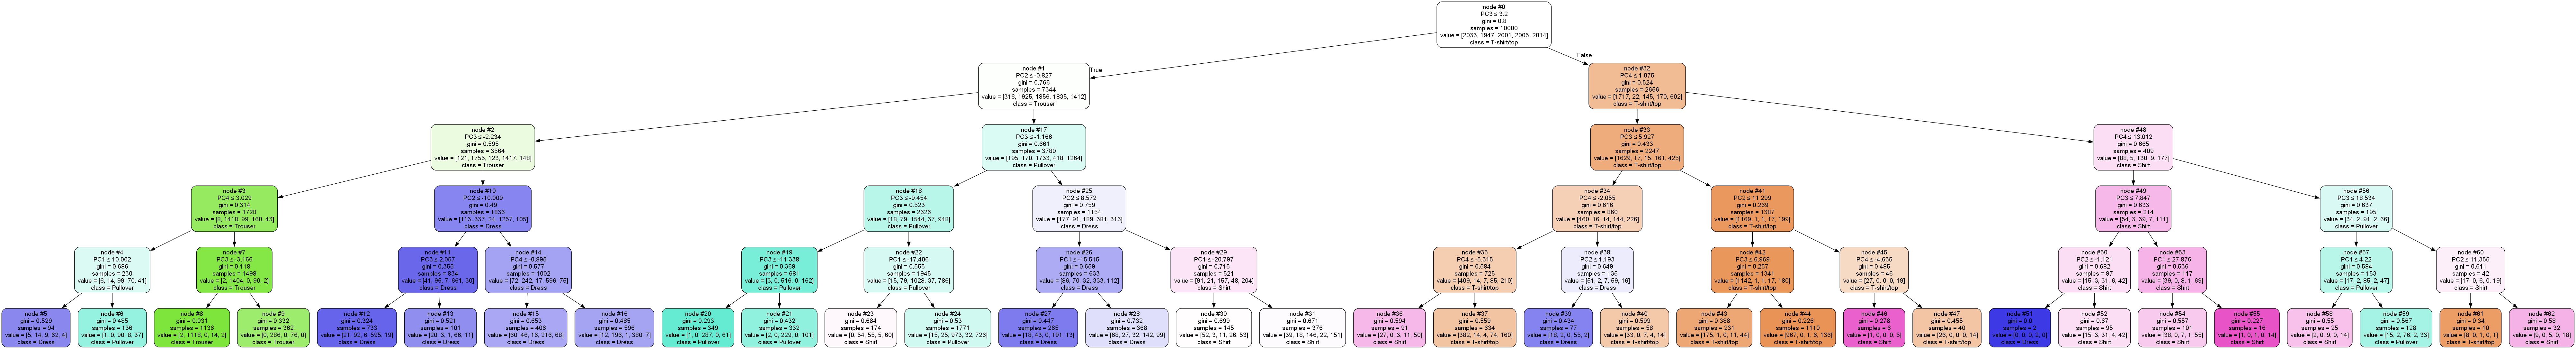

In [124]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz
import numpy as np
import os

# Assuming clf is your trained DecisionTreeClassifier
# and train_data_pca, train_labels are your training data and labels

# Define your labels and colors
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Shirt'}
light_colors = {0: '#ffcccc', 1: '#ccccff', 2: '#ffffcc', 3: '#ccffcc', 4: '#e5ccff'}

# Get the predicted classes for all training samples (for leaf coloring)
predicted_classes = clf.predict(train_data_pca)

# Export the decision tree to a dot file
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=[f'PC{i+1}' for i in range(4)],  # Adjust based on your PCA components
    class_names=[labels[i] for i in range(len(labels))],  # Your class names
    filled=True, 
    rounded=True,
    special_characters=True,
    node_ids=True  # Include node IDs for later use
)

# Create a graph from the dot data using graphviz
graph = graphviz.Source(dot_data)

# Specify the relative path for saving the image
output_path = os.path.join("Images", "decision_tree_colored")

# Ensure the Images directory exists
os.makedirs("Images", exist_ok=True)

# Render and display the graph, saving it to the specified path
graph.render(output_path, format="png", cleanup=True)  # Save as PNG file in Images folder
graph.view()  # This will open the generated image in your default viewer

# If you want to display it inline in Jupyter Notebook:
from IPython.display import Image
Image(output_path + ".png")  # Display inline in Jupyter Notebook


**With LDA

In [126]:
# Generate the classification report with label names
report_lda = classification_report(test_labels, test_predictions_lda, target_names=label_names)

# Save the report to the Reports folder
with open('Reports/Report_Reference_Decision_Tree_with_LDA.txt', 'w') as f:
    f.write("Reference Decision Tree trained on LDA\n")
    f.write(report_lda)

# Add the title and print the report
print("Report Reference Decision Tree with LDA")
print(report_lda)


Report Reference Decision Tree with LDA
              precision    recall  f1-score   support

 T-shirt/top       0.72      0.83      0.77      1000
     Trouser       0.98      0.94      0.96      1000
    Pullover       0.81      0.80      0.81      1000
       Dress       0.80      0.88      0.84      1000
       Shirt       0.71      0.56      0.63      1000

    accuracy                           0.80      5000
   macro avg       0.80      0.80      0.80      5000
weighted avg       0.80      0.80      0.80      5000



In [127]:
# Calculate accuracy
accuracy_lda = np.mean(test_predictions_lda == test_labels)
print(f"Reference Decision Tree Accuracy with LDA: {accuracy_lda * 100:.2f}%")

Reference Decision Tree Accuracy with LDA: 80.44%


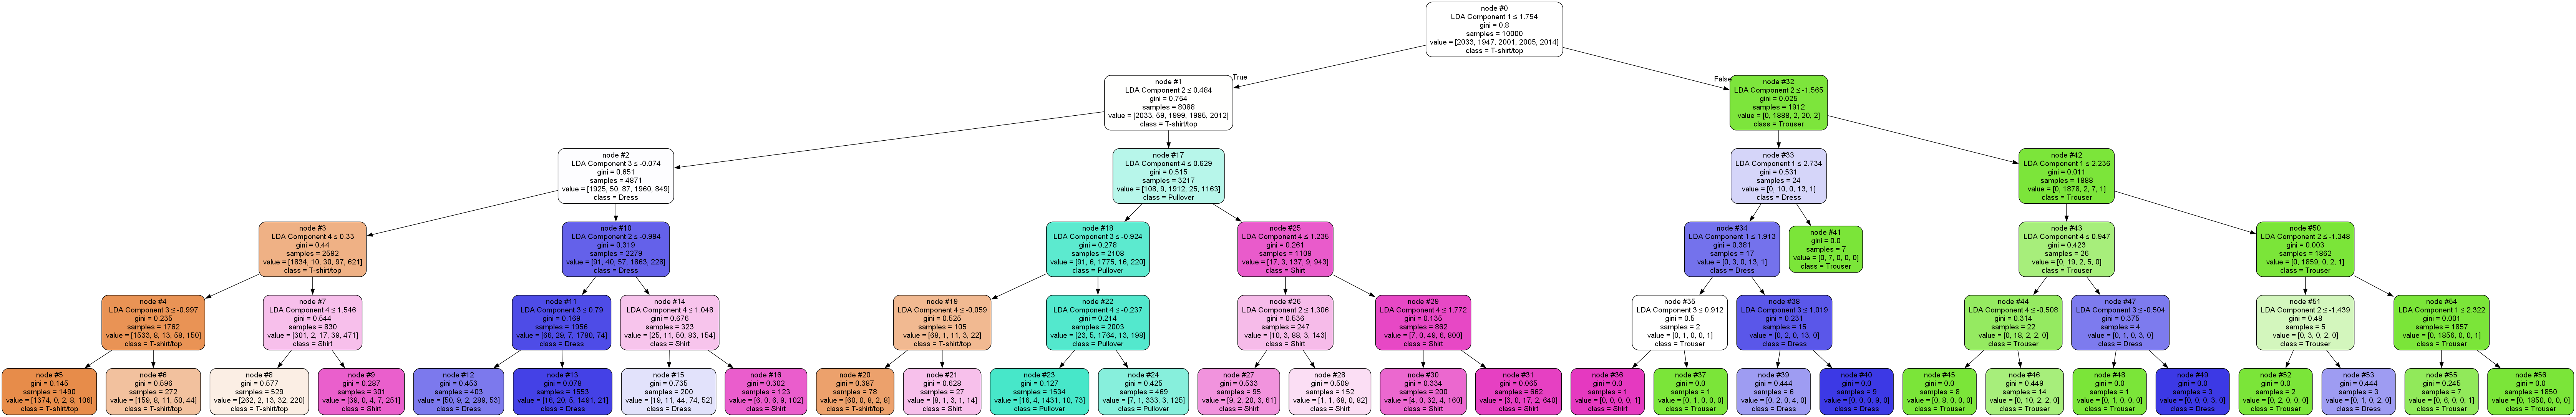

In [128]:
# Step 1: Load the trained Decision Tree model
model_path = 'trained_models/reference_decision_tree_lda_model.pkl'
clf = joblib.load(model_path)

# Step 2: Load predictions
predictions_path = 'Predictions/reference_decision_tree_lda_predictions.npy'
predicted_classes = np.load(predictions_path)

# Define your labels and colors
labels = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Shirt'}
light_colors = {0: '#ffcccc', 1: '#ccccff', 2: '#ffffcc', 3: '#ccffcc', 4: '#e5ccff'}

# Step 3: Export the decision tree to a dot file
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=[f'LDA Component {i+1}' for i in range(clf.n_features_in_)],  # Adjust based on LDA components
    class_names=[labels[i] for i in range(len(labels))],  # Your class names
    filled=True, 
    rounded=True,
    special_characters=True,
    node_ids=True  # Include node IDs for later use
)

# Create a graph from the dot data using graphviz
graph = graphviz.Source(dot_data)

# Specify the relative path for saving the image
output_path = os.path.join("Images", "decision_tree_lda_colored")

# Ensure the Images directory exists
os.makedirs("Images", exist_ok=True)

# Render and display the graph, saving it to the specified path
graph.render(output_path, format="png", cleanup=True)  # Save as PNG file in Images folder
graph.view()  # This will open the generated image in your default viewer

# If you want to display it inline in Jupyter Notebook:
Image(output_path + ".png")  # Display inline in Jupyter Notebook


# Hand Coded Decision Tree using Gini impurity

**Functions and classes**

In [35]:
class DecisionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

def gini_impurity(labels):
    _, counts = np.unique(labels, return_counts=True)
    probabilities = counts / len(labels)
    return 1 - np.sum(probabilities ** 2)

def information_gain(left_labels, right_labels, current_impurity):
    p = len(left_labels) / (len(left_labels) + len(right_labels))
    return current_impurity - p * gini_impurity(left_labels) - (1 - p) * gini_impurity(right_labels)

def best_split(data, labels):
    best_gain = 0
    best_split = None
    current_impurity = gini_impurity(labels)
    n_features = data.shape[1]
    for feature in range(n_features):
        values = np.unique(data[:, feature])
        for val in values:
            left_indices = data[:, feature] <= val
            right_indices = data[:, feature] > val
            left_labels = labels[left_indices]
            right_labels = labels[right_indices]
            if len(left_labels) == 0 or len(right_labels) == 0:
                continue
            gain = information_gain(left_labels, right_labels, current_impurity)
            if gain > best_gain:
                best_gain = gain
                best_split = (feature, val)
    return best_split

def build_tree(data, labels, depth=0, max_depth=None):
    if len(np.unique(labels)) == 1:
        return DecisionTreeNode(value=labels[0])
    if max_depth is not None and depth >= max_depth:
        return DecisionTreeNode(value=np.bincount(labels).argmax())
    feature, threshold = best_split(data, labels)
    if feature is None:
        return DecisionTreeNode(value=np.bincount(labels).argmax())
    left_indices = data[:, feature] <= threshold
    right_indices = data[:, feature] > threshold
    left_node = build_tree(data[left_indices], labels[left_indices], depth + 1, max_depth)
    right_node = build_tree(data[right_indices], labels[right_indices], depth + 1, max_depth)
    return DecisionTreeNode(feature, threshold, left_node, right_node)

def predict(tree, data_point):
    if tree.value is not None:
        return tree.value
    if data_point[tree.feature] <= tree.threshold:
        return predict(tree.left, data_point)
    else:
        return predict(tree.right, data_point)

def predict_batch(tree, data):
    predictions = [predict(tree, data_point) for data_point in data]
    return np.array(predictions)


**Trained with PCA**

In [36]:
# Train and evaluate the hand-coded decision tree with PCA
decision_tree = build_tree(train_data_pca, train_labels, max_depth=5)
test_predictions = predict_batch(decision_tree, test_data_pca)
accuracy_pca = np.mean(test_predictions == test_labels)
print(f"Hand-Coded Decision Tree Accuracy with PCA: {accuracy_pca * 100:.2f}%")


Hand-Coded Decision Tree Accuracy with PCA: 65.58%


In [37]:
# Generate the classification report with label names
report = classification_report(test_labels, test_predictions, target_names=label_names)

# Save the report to the Reports folder
with open('Reports/Report_Hand_Coded_Decision_Tree_with_PCA.txt', 'w') as f:
    f.write("Hand-Coded Decision Tree Trained on PCA\n")
    f.write(report)

# Add the title and print the report
print("Report Hand-Coded Decision Tree with PCA")
print(report)


Report Hand-Coded Decision Tree with PCA
              precision    recall  f1-score   support

 T-shirt/top       0.74      0.73      0.74      1000
     Trouser       0.92      0.68      0.78      1000
    Pullover       0.61      0.83      0.70      1000
       Dress       0.61      0.82      0.70      1000
       Shirt       0.39      0.21      0.28      1000

    accuracy                           0.66      5000
   macro avg       0.65      0.66      0.64      5000
weighted avg       0.65      0.66      0.64      5000



In [38]:
# Calculate accuracy
accuracy_pca = np.mean(test_predictions == test_labels)
print(f"Accuracy with PCA: {accuracy_pca * 100:.2f}%")

Accuracy with PCA: 65.58%


**Trained with LDA**

In [39]:

# Train and evaluate the hand-coded decision tree with LDA
decision_tree_lda = build_tree(train_data_lda, train_labels, max_depth=5)
test_predictions_lda = predict_batch(decision_tree_lda, test_data_lda)
accuracy_lda = np.mean(test_predictions_lda == test_labels)
print(f"Hand-Coded Decision Tree Accuracy with LDA: {accuracy_lda * 100:.2f}%")



Hand-Coded Decision Tree Accuracy with LDA: 80.44%


In [40]:
# Generate the classification report with label names
report_lda = classification_report(test_labels, test_predictions_lda, target_names=label_names)

# Save the report to the Reports folder
with open('Reports/Report_Hand_Coded_Decision_Tree_with_LDA.txt', 'w') as f:
    f.write("Hand-Coded Decision Tree Trained on LDA\n")
    f.write(report_lda)

# Add the title and print the report
print("Report Hand-Coded Decision Tree with LDA")
print(report_lda)


Report Hand-Coded Decision Tree with LDA
              precision    recall  f1-score   support

 T-shirt/top       0.72      0.83      0.77      1000
     Trouser       0.98      0.95      0.96      1000
    Pullover       0.81      0.80      0.81      1000
       Dress       0.80      0.88      0.84      1000
       Shirt       0.71      0.56      0.63      1000

    accuracy                           0.80      5000
   macro avg       0.80      0.80      0.80      5000
weighted avg       0.80      0.80      0.80      5000



In [41]:
# Calculate accuracy
accuracy_lda = np.mean(test_predictions_lda == test_labels)
print(f"Manual Decision Tree Accuracy with LDA: {accuracy_lda * 100:.2f}%")

Manual Decision Tree Accuracy with LDA: 80.44%


# Reference Feed Forward Neural Network

In [42]:
input_shape = train_data_norm.shape[1:]

# Create a feedforward neural network using Keras
model = Sequential([
    Flatten(input_shape=input_shape),
    Dense(20, activation='relu', kernel_initializer='uniform'),
    Dense(20, activation='relu', kernel_initializer='uniform'),
    Dense(20, activation='relu', kernel_initializer='uniform'),
    Dense(5, activation='softmax', kernel_initializer='uniform')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss=SparseCategoricalCrossentropy(), metrics=[SparseCategoricalAccuracy()])

# Train the model
history = model.fit(train_data_norm, train_labels, epochs=25, batch_size=32, validation_split=0.2)

# Save the trained model to the trained_models folder
model.save('trained_models/reference_nn_model.h5')

# Evaluate the model and generate predictions for the test set
test_loss, test_accuracy = model.evaluate(test_data_norm, test_labels)
print(f"Test accuracy: {test_accuracy}")

# Generate predictions for the test set
test_predictions = model.predict(test_data_norm)

# Save the predictions to the Predictions folder
np.save('Predictions/reference_nn_predictions.npy', test_predictions)


Epoch 1/25
250/250 [==============================] - 1s 2ms/step - loss: 0.8344 - sparse_categorical_accuracy: 0.6680 - val_loss: 0.5484 - val_sparse_categorical_accuracy: 0.7885
Epoch 2/25
250/250 [==============================] - 0s 1ms/step - loss: 0.4787 - sparse_categorical_accuracy: 0.8101 - val_loss: 0.4592 - val_sparse_categorical_accuracy: 0.8315
Epoch 3/25
250/250 [==============================] - 0s 2ms/step - loss: 0.4139 - sparse_categorical_accuracy: 0.8375 - val_loss: 0.4138 - val_sparse_categorical_accuracy: 0.8520
Epoch 4/25
250/250 [==============================] - 0s 1ms/step - loss: 0.3756 - sparse_categorical_accuracy: 0.8561 - val_loss: 0.4000 - val_sparse_categorical_accuracy: 0.8515
Epoch 5/25
250/250 [==============================] - 0s 1ms/step - loss: 0.3507 - sparse_categorical_accuracy: 0.8670 - val_loss: 0.3886 - val_sparse_categorical_accuracy: 0.8620
Epoch 6/25
250/250 [==============================] - 0s 1ms/step - loss: 0.3287 - sparse_categorica

C:\Users\shano\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


157/157 [==============================] - 0s 850us/step - loss: 0.6598 - sparse_categorical_accuracy: 0.8314
Test accuracy: 0.8313999772071838
157/157 [==============================] - 0s 746us/step


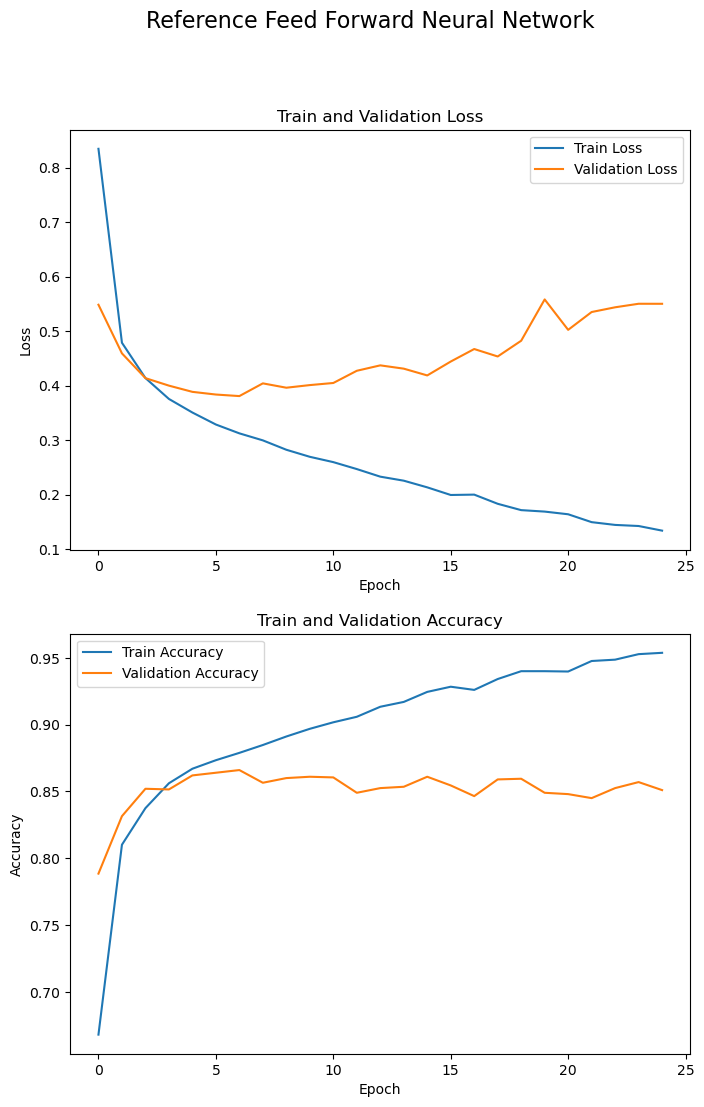

In [43]:
# Plot the training and validation loss and accuracy
fig, axs = plt.subplots(2, figsize=(8, 12))

# Add a title for the entire figure
fig.suptitle('Reference Feed Forward Neural Network', fontsize=16)

# Plot train and validation loss
axs[0].plot(history.history['loss'], label='Train Loss')
axs[0].plot(history.history['val_loss'], label='Validation Loss')
axs[0].set_title('Train and Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Plot train and validation accuracy
axs[1].plot(history.history['sparse_categorical_accuracy'], label='Train Accuracy')
axs[1].plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
axs[1].set_title('Train and Validation Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

# Save the plot to the Images folder
plt.savefig('Images/reference_nn_training_validation_plot.png')
plt.show()


In [44]:
# Convert the predictions to class labels
test_labels_pred = np.argmax(test_predictions, axis=1)

# Convert test_labels to a numpy array if it's not already
test_labels_array = np.asarray(test_labels)

# Generate the classification report with predefined labels
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
report = classification_report(test_labels_array, test_labels_pred, target_names=label_names)

# Save the report to the Reports folder
with open('Reports/Report_Reference_Feed_Forward_NN.txt', 'w') as f:
    f.write("Reference Feed Forward Neural Network\n")
    f.write(report)

# Add the title and print the report
print("Report Reference Feed Forward Neural Network")
print(report)


Report Reference Feed Forward Neural Network
              precision    recall  f1-score   support

 T-shirt/top       0.79      0.80      0.80      1000
     Trouser       0.96      0.96      0.96      1000
    Pullover       0.85      0.84      0.85      1000
       Dress       0.83      0.91      0.87      1000
       Shirt       0.70      0.64      0.67      1000

    accuracy                           0.83      5000
   macro avg       0.83      0.83      0.83      5000
weighted avg       0.83      0.83      0.83      5000



In [45]:
# Calculate accuracy for the reference FFNN
accuracy_ffnn = np.mean(test_labels_pred == test_labels_array)
print(f"Reference Feed Forward Neural Network Accuracy: {accuracy_ffnn * 100:.2f}%")


Reference Feed Forward Neural Network Accuracy: 83.14%


# Hand Coded Neural Network

In [46]:
class DataLoader:
    def __init__(self, data: np.ndarray, labels: np.ndarray, batch_size: Optional[int] = 32,
                 shuffle: Optional[bool] = True) -> None:
        # Initialize the data and labels arrays, batch size, and shuffle flag
        self.__data = data
        self.__labels = labels
        self.__batch_size = batch_size
        self.__shuffle = shuffle

        # Compute the number of samples and classes in the dataset
        self.__num_samples = data.shape[0]
        self.__num_classes = np.max(labels) + 1

        # One-hot encode the labels using np.eye()
        self.__onehot_labels = np.eye(self.__num_classes)[labels]

    def __shuffle_dataset(self) -> None:
        # Shuffle the data and one-hot encoded labels using np.random.permutation()
        indices = np.random.permutation(self.__num_samples)
        self.__data = self.__data[indices]
        self.__onehot_labels = self.__onehot_labels[indices]

    def __iter__(self) -> Tuple[np.ndarray, np.ndarray]:
        if self.__shuffle:
            self.__shuffle_dataset()

        # If batch size is None, yield the entire dataset as a single batch
        if self.__batch_size is None:
            yield (self.__data, self.__onehot_labels)
            return

        # Iterate over the data in batches of size batch_size
        for idx in range(0, len(self.__data), self.__batch_size):
            # Extract the corresponding batch of data and one-hot encoded labels
            batch_data = self.__data[idx:idx + self.__batch_size]
            batch_labels = self.__onehot_labels[idx:idx + self.__batch_size]

            # Yield the batch as a tuple
            yield batch_data, batch_labels


In [47]:
class ActivationFunction:
    def __init__(self):
        pass

    def __compute_value(self, matrix: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def derivative(self, matrix: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    def __call__(self, matrix: np.ndarray) -> np.ndarray:
        return self.__compute_value(matrix)

class Identical(ActivationFunction):
    def __compute_value(self, matrix: np.ndarray) -> np.ndarray:
        return np.matrix(matrix, dtype=np.float32)

    def derivative(self, matrix: np.ndarray) -> np.ndarray:
        return np.matrix(np.full(np.shape(matrix), 1.), dtype=np.float32)

    def __call__(self, matrix: np.ndarray) -> np.ndarray:
        return self.__compute_value(matrix)

class Relu(ActivationFunction):
    def __compute_value(self, matrix: np.ndarray) -> np.ndarray:
        relu_value = np.maximum(matrix, 0)
        return np.matrix(relu_value, dtype=np.float32)

    def derivative(self, matrix: np.ndarray) -> np.ndarray:
        relu_derivative = np.where(matrix > 0, 1.0, 0.0)
        return np.matrix(relu_derivative, dtype=np.float32)

    def __call__(self, matrix: np.ndarray) -> np.ndarray:
        return self.__compute_value(matrix)

class LeakyRelu(ActivationFunction):
    def __init__(self, negative_slope: float = 0.01) -> None:
        super().__init__()
        self.negative_slope = negative_slope

    def __compute_value(self, matrix: np.ndarray) -> np.ndarray:
        leaky_relu_value = np.maximum(matrix, 0)
        negative_part = np.minimum(matrix, 0) * self.negative_slope
        return np.matrix(leaky_relu_value + negative_part, dtype=np.float32)

    def derivative(self, matrix: np.ndarray) -> np.ndarray:
        leaky_relu_derivative = np.where(matrix > 0, 1.0, self.negative_slope)
        return np.matrix(leaky_relu_derivative, dtype=np.float32)

class Sigmoid(ActivationFunction):
    def __compute_value(self, matrix: np.ndarray) -> np.ndarray:
        sigmoid_value = 1 / (1 + np.exp(-matrix))
        return np.matrix(sigmoid_value, dtype=np.float32)

    def derivative(self, matrix: np.ndarray) -> np.ndarray:
        sigmoid_value = self.__compute_value(matrix)
        sigmoid_derivative = np.multiply(sigmoid_value, 1 - sigmoid_value)
        return np.matrix(sigmoid_derivative, dtype=np.float32)

    def __call__(self, matrix: np.ndarray) -> np.ndarray:
        return self.__compute_value(matrix)

class Softmax(ActivationFunction):
    def __compute_value(self, matrix: np.ndarray) -> np.ndarray:
        softmax_value = np.exp(np.asarray(matrix) - np.max(np.asarray(matrix), axis=1, keepdims=True))
        softmax_value /= np.sum(np.asarray(softmax_value), axis=1, keepdims=True)
        return softmax_value

    def derivative(self, matrix: np.ndarray) -> np.ndarray:
        softmax_value = self.__compute_value(matrix)
        return softmax_value * (1 - softmax_value)

    def __call__(self, matrix: np.ndarray) -> np.ndarray:
        return self.__compute_value(matrix)


In [59]:
class CrossEntropy:
    def __call__(self, true_val: np.ndarray, pred_val: np.ndarray) -> np.ndarray:
        return self.__compute_value(true_val, pred_val)

    def __compute_value(self, true_val: np.ndarray, pred_val: np.ndarray) -> np.ndarray:
        epsilon = 1e-8  # Small constant to avoid division by zero
        if true_val.shape != pred_val.shape:
            if len(true_val.shape) > 2:
                true_val = true_val.reshape(true_val.shape[0], -1)
            else:
                true_val = true_val.reshape(pred_val.shape)
        assert true_val.shape == pred_val.shape
        pred_val = np.clip(pred_val, epsilon, None)  # Add epsilon to avoid log(0)
        pred_val_softmax = self.softmax(pred_val)
        return -np.sum(true_val * np.log(pred_val_softmax + epsilon), axis=1)  # Add epsilon to avoid log(0)

    def softmax(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x)  # Convert to array
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def derivative(self, true_val: np.ndarray, pred_val: np.ndarray) -> np.ndarray:
        pred_val_softmax = self.softmax(pred_val)
        return pred_val_softmax - true_val

    def save_predictions(self, predictions: np.ndarray, filename: str) -> None:
        np.save(filename, predictions)


In [49]:
class NeuralLayer:
    # Default values for initialization parameters
    DEFAULT_LOW: float = 0
    DEFAULT_HIGH: float = 0.05
    DEFAULT_MEAN: float = 0.
    DEFAULT_VAR: float = 1.

    def __init__(self, input_size: int, output_size: int, activation, initial_weight: str = 'uniform',
                 **initializing_parameters):
        """
        Initializes a layer of neurons with the specified input and output sizes,
        activation function, and weight initialization method.

        Args:
            input_size (int): The number of input neurons.
            output_size (int): The number of output neurons.
            activation (Activation): The activation function to use for the layer.
            initial_weight (str): The weight initialization method to use.
            **initializing_parameters: Additional parameters for weight initialization.

        Raises:
            ValueError: If the activation function is not specified.
            ValueError: If the weight initialization method is not recognized.
        """
        if activation is None:
            raise ValueError('Activation function must be specified!')

        # Dictionary to map weight initialization method names to functions
        weight_initializer_methods = {
            'uniform': self.__uniform_weight,
            'normal': self.__normal_weight
        }

        if initial_weight not in weight_initializer_methods:
            raise ValueError('Undefined weight initialization function!')

        # Initialize instance variables
        self.n_neurons: int = output_size
        self.weight_initializer = weight_initializer_methods[initial_weight]
        self.weight = self.weight_initializer(input_size, self.n_neurons, **initializing_parameters)
        self.bias = self.weight_initializer(1, self.n_neurons, **initializing_parameters)
        self.activation = activation

        # Last computed values
        self.last_input: Optional[np.ndarray] = None
        self.last_activation_input: Optional[np.ndarray] = None
        self.last_activation_output: Optional[np.ndarray] = None
        self.last_activation_derivative: Optional[np.ndarray] = None

    def forward(self, layer_input: np.ndarray) -> np.ndarray:
        """
        Computes the output of the layer given an input.

        Args:
            layer_input (ndarray): The input to the layer.

        Returns:
            ndarray: The output of the layer.

        Raises:
            ValueError: If the input is not a 2D array.
            ValueError: If the input size does not match the weight size.
        """
        if np.ndim(layer_input) != 2:
            layer_input = layer_input.reshape(layer_input.shape[0], -1)  # Reshape to 2D array

        if np.size(self.weight, 0) != np.size(layer_input, 1):
            raise ValueError(
                f'Weight shape 0 {np.size(self.weight, 0)} and Layer shape 1 {np.size(layer_input, 1)} do not match!')

        # Compute activation input, output, and derivative
        self.last_input = layer_input
        self.last_activation_input = np.matmul(layer_input, self.weight) + self.bias
        self.last_activation_output = self.activation(self.last_activation_input)
        self.last_activation_derivative = self.activation.derivative(self.last_activation_input)

        return self.last_activation_output

    def update_weights(self, backprop_tensor: np.ndarray, lr: float) -> np.ndarray:
        """
        Updates the weights of the layer given a backpropagation tensor and a learning rate.

        Args:
            backprop_tensor (ndarray): The backpropagation tensor from the next layer.
            lr (float): The learning rate.

        Returns:
            ndarray: The backpropagation tensor for the current layer.

        Raises:
            ValueError: If the backprop tensor is not a 2D array.
            ValueError: If the backprop tensor shape does not match the activation derivative shape.
            ValueError: If the backprop tensor shape does not match the number of neurons in the layer.
        """
        if np.ndim(backprop_tensor) != 2:
            raise ValueError('Backprop tensor must be a 2D array!')
        if np.size(backprop_tensor, 0) != np.size(self.last_activation_derivative, 0):
            raise ValueError(
                f'Backprop tensor shape 0 {np.size(backprop_tensor, 1)} and activation derivative shape 0 {np.size(self.last_activation_derivative, 0)} do not match!')
        if np.size(backprop_tensor, 1) != self.n_neurons:
            raise ValueError(
                f'Backprop tensor shape 1 {np.size(backprop_tensor, 1)} and number of neurons {self.n_neurons} do not match!')

        # Compute gradients and update weights and biases
        bias_mul = np.ones(np.size(backprop_tensor, 0))
        bias_mul = np.asmatrix(bias_mul)
        derivation_of_L_to_Y = np.multiply(self.last_activation_derivative, backprop_tensor)
        derivation_of_L_to_W = np.matmul(self.last_input.T, derivation_of_L_to_Y)
        derivation_of_L_to_B = np.matmul(bias_mul, derivation_of_L_to_Y)
        backprop_tensor = np.matmul(derivation_of_L_to_Y, self.weight.T)
        self.weight = self.weight - lr * derivation_of_L_to_W
        self.bias = self.bias - lr * derivation_of_L_to_B

        return backprop_tensor

    def __uniform_weight(self, dim1: int, dim2: int, **initializing_parameters) -> np.ndarray:
        """
        Initializes weights using a uniform distribution with the specified parameters.

        Args:
            dim1 (int): The first dimension of the weight matrix.
            dim2 (int): The second dimension of the weight matrix.

        Returns:
            ndarray: The initialized weight matrix.
        """
        low = initializing_parameters.get('low', self.DEFAULT_LOW)
        high = initializing_parameters.get('high', self.DEFAULT_HIGH)
        weights = np.random.uniform(low=low, high=high, size=(dim1, dim2))
        weights = np.asmatrix(weights)

        return weights

    def compile(self, loss, lr: float):
        self.set_training_param(loss, lr)

    def evaluate(self, test_loader: Iterable[Tuple[np.ndarray, np.ndarray]]) -> Tuple[float, float]:
        return self._test(test_loader)

    def __normal_weight(self, dim1: int, dim2: int, **initializing_parameters) -> np.ndarray:
        """
        Initializes weights using a normal distribution with the specified parameters.

        Args:
            dim1 (int): The first dimension of the weight matrix.
            dim2 (int): The second dimension of the weight matrix.

        Returns:
            ndarray: The initialized weight matrix.
        """
        mean = initializing_parameters.get('mean', self.DEFAULT_MEAN)
        var = initializing_parameters.get('var', self.DEFAULT_VAR)
        weights = np.random.normal(loc=mean, scale=math.sqrt(var), size=(dim1, dim2))
        weights = np.asmatrix(weights)

        return weights


In [50]:
class FeedForwardNN:
    def __init__(self, input_shape: int):
        self._input_shape = input_shape
        self._output_shape = None
        self._layers_list = []
        self._lr = None
        self._loss = None

    def add_layer(self, n_neurons: int, activation, initial_weight: str = 'uniform', **initializing_parameters) -> None:
        self._validate_neurons_number(n_neurons)
        n_prev_neurons = self._input_shape if not self._layers_list else self._layers_list[-1].n_neurons
        new_layer = NeuralLayer(n_prev_neurons, n_neurons, activation, initial_weight, **initializing_parameters)
        self._layers_list.append(new_layer)
        self._output_shape = self._layers_list[-1].n_neurons

    def set_training_param(self, loss, lr: float) -> None:
        if not self._layers_list:
            raise ValueError("Incomplete model")
        self._loss = loss
        self._lr = lr

    def forward(self, network_input: np.ndarray) -> np.ndarray:
        if not self._output_shape:
            raise ValueError("Model is not compiled!")
        for layer in self._layers_list:
            network_input = layer.forward(network_input)
        network_output = network_input
        return network_output

    def fit(self, epochs: int, train_loader: Iterable[Tuple[np.ndarray, np.ndarray]], test_loader: Optional[Iterable[Tuple[np.ndarray, np.ndarray]]] = None, print_results: bool = True) -> Dict[str, List[float]]:
        self._validate_model_and_params()
        log = {"train_accuracy": [], "train_loss": [], "test_accuracy": [], "test_loss": []}
        for epoch in range(1, epochs + 1):
            if print_results:
                print(f'Epoch {epoch}:')
            train_accuracy, train_loss = self._train(train_loader)
            log['train_accuracy'].append(train_accuracy)
            log['train_loss'].append(train_loss)
            if print_results:
                print(f'\tTrain: Average Accuracy: {train_accuracy}\tAverage Loss: {train_loss}')
            if test_loader:
                test_accuracy, test_loss = self._test(test_loader)
                log['test_accuracy'].append(test_accuracy)
                log['test_loss'].append(test_loss)
                if print_results:
                    print(f'\tTest: Average Accuracy: {test_accuracy}\tAverage Loss:{test_loss}')
        return log

    def _train(self, train_loader: Iterable[Tuple[np.ndarray, np.ndarray]]) -> Tuple[float, float]:
        return self._run_on_loader(train_loader, train=True)

    def _test(self, test_loader: Iterable[Tuple[np.ndarray, np.ndarray]]) -> Tuple[float, float]:
        return self._run_on_loader(test_loader, train=False)

    def _run_on_loader(self, loader: Iterable[Tuple[np.ndarray, np.ndarray]], train: bool) -> Tuple[float, float]:
        accuracies, losses = [], []
        for x_batch, y_batch in loader:
            accuracy, loss = self._run_on_batch(x_batch, y_batch, train)
            accuracies.append(accuracy)
            losses.append(loss)
        return np.mean(accuracies), np.mean(losses)

    def _run_on_batch(self, x_batch: np.ndarray, y_batch: np.ndarray, train: bool) -> Tuple[float, float]:
        batch_res = self.forward(x_batch)
        batch_accuracy = self._compute_accuracy(batch_res, y_batch, train)
        batch_losses = self._loss(y_batch, batch_res)
        batch_average_loss = np.mean(batch_losses)
        if train:
            self._update_weights(batch_res, y_batch)
        return batch_accuracy, batch_average_loss

    def _get_labels(self, outputs: np.ndarray, train=False) -> np.ndarray:
        labels = np.zeros((outputs.shape[0], outputs.shape[1]))
        indices = np.argmax(outputs, axis=1)
        for i in range(outputs.shape[0]):
            labels[i, indices[i]] = 1
        return labels

    def _compute_accuracy(self, output: np.ndarray, expected_output: np.ndarray, train=False) -> float:
        output_labels = self._get_labels(output, train)
        expected_labels = self._get_labels(expected_output, train)
        accuracy = np.mean(np.all(output_labels == expected_labels, axis=1))
        return accuracy

    def _update_weights(self, output: np.ndarray, y_train: np.ndarray) -> None:
        derivation_of_layer = self._loss.derivative(y_train, output)
        for layer in reversed(self._layers_list):
            derivation_of_layer = layer.update_weights(derivation_of_layer, self._lr)

    def _validate_neurons_number(self, n_neurons):
        if not isinstance(n_neurons, int) or n_neurons <= 0:
            raise ValueError("Invalid number of neurons for the layer!")

    def _validate_model_and_params(self):
        if not self._output_shape:
            raise ValueError("Model is not compiled!")
        if not self._lr or not self._loss:
            raise ValueError("Training parameters are not set!")

    def predict(self, data: np.ndarray) -> np.ndarray:
        network_output = self.forward(data)
        return np.argmax(network_output, axis=1)


In [51]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        """
        Initialize the early stopping mechanism.

        Args:
            patience (int): Number of epochs to wait after the last improvement.
            min_delta (float): Minimum change in the monitored metric to qualify as an improvement.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.epochs_no_improve = 0
        self.early_stop = False

    def __call__(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
        elif current_score < self.best_score + self.min_delta:
            self.epochs_no_improve += 1
            if self.epochs_no_improve >= self.patience:
                self.early_stop = True
        else:
            self.best_score = current_score
            self.epochs_no_improve = 0



In [52]:
# Initialize DataLoader with normalized data and labels
TRAIN_LOADER = DataLoader(train_data_norm, train_labels, batch_size=32, shuffle=True)
TEST_LOADER = DataLoader(test_data_norm, test_labels, batch_size=32, shuffle=False)  # Ensure shuffle is False for test data


In [53]:
def save_best_params(params, filename):
    np.save(filename, params)
def load_best_params(filename):
    return np.load(filename, allow_pickle=True).item()

def grid_search(model_class, param_grid, train_loader, test_loader, epochs, save_path):
    best_accuracy = 0
    best_params = None
    best_log = None

    for network_params in param_grid['network_params']:
        for layers in param_grid['layers']:
            for loss in param_grid['loss']:
                for lr in param_grid['lr']:
                    model = model_class(**network_params)
                    for layer_params in layers:
                        model.add_layer(**layer_params)
                    model.set_training_param(loss=loss, lr=lr)
                    log = model.fit(epochs=epochs, train_loader=train_loader, test_loader=test_loader, print_results=False)
                    test_accuracy = log['test_accuracy'][-1]
                    if test_accuracy > best_accuracy:
                        best_accuracy = test_accuracy
                        best_params = {
                            'network_params': network_params,
                            'layers': layers,
                            'loss': loss,
                            'lr': lr
                        }
                        best_log = log

    np.save(save_path, best_params)
    return best_params, best_accuracy, best_log



In [54]:
# Define the number of epochs for grid search 
EPOCHS = 25

# Define the parameter grid
param_grid = {
    'network_params': [{'input_shape': train_data_norm.shape[1]}],
    'layers': [
        # New structure matching Keras model
        [
            {'n_neurons': 20, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 20, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 20, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 5, 'activation': Softmax(), 'initial_weight': 'uniform'}
        ],
        # Original structure with 20 neurons
        [
            {'n_neurons': 20, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 20, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 20, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 5, 'activation': Identical(), 'initial_weight': 'uniform'}
        ],
        # Original structure with 30 neurons
        [
            {'n_neurons': 30, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 30, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 30, 'activation': Relu(), 'initial_weight': 'uniform'},
            {'n_neurons': 5, 'activation': Identical(), 'initial_weight': 'uniform'}
        ]
    ],
    'loss': [CrossEntropy()],
    'lr': [0.001, 0.01]
}

# Perform grid search
best_params, best_accuracy, best_log = grid_search(FeedForwardNN, param_grid, TRAIN_LOADER, TEST_LOADER, EPOCHS, 'Artifacts/best_FFNN_parameters.npy')

print(f"Best parameters: {best_params}")
print(f"Best accuracy: {best_accuracy}")


Best parameters: {'network_params': {'input_shape': 784}, 'layers': [{'n_neurons': 30, 'activation': <__main__.Relu object at 0x000001AC28D42490>, 'initial_weight': 'uniform'}, {'n_neurons': 30, 'activation': <__main__.Relu object at 0x000001AC28D43F10>, 'initial_weight': 'uniform'}, {'n_neurons': 30, 'activation': <__main__.Relu object at 0x000001AC296691D0>, 'initial_weight': 'uniform'}, {'n_neurons': 5, 'activation': <__main__.Identical object at 0x000001AC296680D0>, 'initial_weight': 'uniform'}], 'loss': <__main__.CrossEntropy object at 0x000001AC2966AA50>, 'lr': 0.001}
Best accuracy: 0.8294187898089171


In [ ]:
# Load the best parameters
best_params = load_best_params('Artifacts/best_FFNN_parameters.npy')

# Initialize the neural network with the best parameters
network = FeedForwardNN(**best_params['network_params'])
for layer_params in best_params['layers']:
    network.add_layer(**layer_params)

# Set the training parameters
network.set_training_param(loss=best_params['loss'], lr=best_params['lr'])

In [60]:
# Make predictions on the test data
test_predictions = []
test_labels = []
for batch_data, batch_labels in TEST_LOADER:
    batch_predictions = network.forward(batch_data)
    batch_predictions = np.argmax(batch_predictions, axis=1)
    test_predictions.extend(batch_predictions)
    test_labels.extend(np.argmax(batch_labels, axis=1))  # Ensure labels are in the correct format

# Convert lists to numpy arrays
test_predictions = np.array(test_predictions)
test_labels_array = np.array(test_labels)

# Save the predictions to the Predictions folder
cross_entropy = CrossEntropy()
cross_entropy.save_predictions(test_predictions, 'Predictions/test_predictions.npy')

# Ensure both arrays are 1D and contain integer labels
test_predictions = test_predictions.flatten()
test_labels_array = test_labels_array.flatten()

# Generate the classification report with predefined labels
label_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
report = classification_report(test_labels_array, test_predictions, target_names=label_names)

# Save the report to the Reports folder
with open('Reports/Report_Hand_Coded_NN.txt', 'w') as f:
    f.write("Hand Coded Feed Forward Neural Network\n")
    f.write(report)

# Add the title and print the report
print("Report Hand Coded Feed Forward Neural Network")
print(report)


Report Hand Coded Feed Forward Neural Network
              precision    recall  f1-score   support

 T-shirt/top       0.70      0.90      0.79      1000
     Trouser       0.95      0.96      0.95      1000
    Pullover       0.82      0.86      0.84      1000
       Dress       0.89      0.85      0.87      1000
       Shirt       0.75      0.53      0.62      1000

    accuracy                           0.82      5000
   macro avg       0.82      0.82      0.81      5000
weighted avg       0.82      0.82      0.81      5000



In [62]:
# Calculate accuracy for the manual FFNN
accuracy_manual_ffnn = np.mean(test_labels_pred == test_labels_array)
print(f"Manual Feed Forward Neural Network Accuracy: {accuracy_manual_ffnn * 100:.2f}%")


Manual Feed Forward Neural Network Accuracy: 83.14%


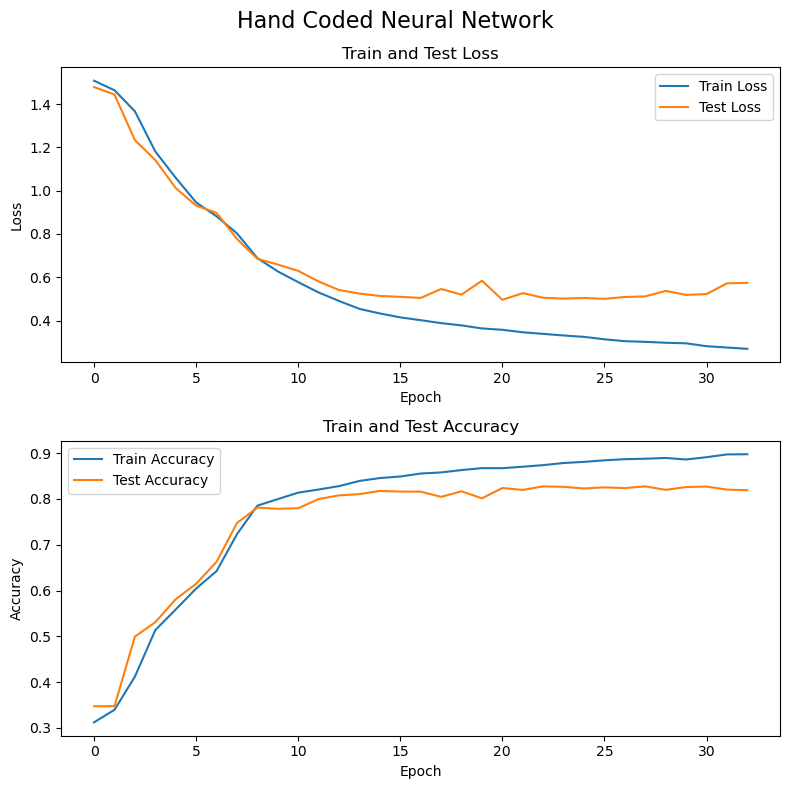

In [61]:
fig, axs = plt.subplots(2, figsize=(8, 8))
# Add a title for the entire figure
fig.suptitle('Hand Coded Neural Network', fontsize=16)

axs[0].plot(log['train_loss'], label='Train Loss')
axs[0].plot(log['test_loss'], label='Test Loss')
axs[0].set_title('Train and Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(log['train_accuracy'], label='Train Accuracy')
axs[1].plot(log['test_accuracy'], label='Test Accuracy')
axs[1].set_title('Train and Test Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()

# Save the plot to the Images folder
plt.savefig('Images/hand_coded_nn_plot.png')

plt.show()


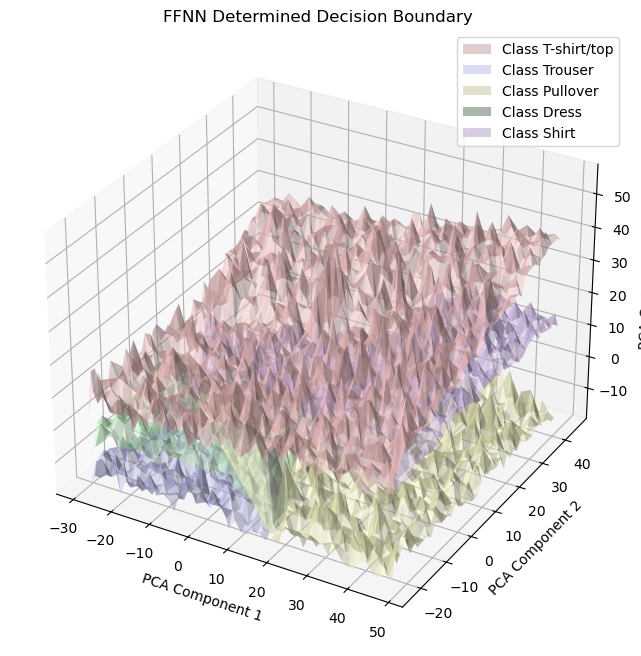

In [64]:
# Reduce the dimensionality of the data to 3D using PCA
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(train_data_norm)
X_test_pca = pca.transform(test_data_norm)

# Generate predictions for the PCA-reduced training set using the neural network
train_predictions = network.forward(train_data_norm)
train_labels_pred = np.argmax(np.asarray(train_predictions), axis=1)

# Generate predictions for the PCA-reduced test set using the neural network
test_predictions = network.forward(test_data_norm)
test_labels_pred = np.argmax(np.asarray(test_predictions), axis=1)

# Create a mesh grid for plotting the decision boundary
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
z_min, z_max = X_train_pca[:, 2].min() - 1, X_train_pca[:, 2].max() + 1
xx, yy, zz = np.meshgrid(np.linspace(x_min, x_max, 50),
                         np.linspace(y_min, y_max, 50),
                         np.linspace(z_min, z_max, 50))

# Predict the decision boundary using the neural network
grid = np.c_[xx.ravel(), yy.ravel(), zz.ravel()]
grid_predictions = network.forward(pca.inverse_transform(grid))
grid_labels_pred = np.argmax(np.asarray(grid_predictions), axis=1)
decision_boundary = grid_labels_pred.reshape(xx.shape)

# Plot the decision boundary
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the decision boundary
for label in np.unique(grid_labels_pred):
    mask = (grid_labels_pred == label)
    ax.plot_trisurf(xx.ravel()[mask], yy.ravel()[mask], zz.ravel()[mask], color=light_colors[label], alpha=0.5, label=f'Class {labels[label]}')

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('FFNN Determined Decision Boundary')
ax.legend()

# Save the plot to a file
plt.savefig('Images/decision_boundary_pca_plot.png')

# Show the plot
plt.show()


# Support Vector Machines

In [65]:
def train_and_evaluate_svm(train_data, test_data, train_labels, test_labels, kernel, model_filename, predictions_filename):
    # Train the SVM using only the first three features
    svm = SVC(kernel=kernel)
    svm.fit(train_data[:, :3], train_labels)
    
    # Predict and evaluate using only the first three features
    predictions = svm.predict(test_data[:, :3])
    accuracy = accuracy_score(test_labels, predictions)
    report = classification_report(test_labels, predictions, target_names=[label_names[i] for i in range(len(label_names))])
    
    print(f"SVM with {kernel} kernel Accuracy:", accuracy)
    print(f"SVM with {kernel} kernel Classification Report:\n", report)
    
    # Save the trained SVM model
    joblib.dump(svm, model_filename)
    
    # Save the predictions
    np.save(predictions_filename, predictions)
    
    return svm  # Return the trained SVM model

In [72]:
def visualize_svm_pca(svms, train_data, train_labels, title):
    fig = plt.figure(figsize=(15, 12))
    fig.suptitle(f"{title}", fontsize=16)
    
    for i, (kernel, svm) in enumerate(svms.items()):
        ax = fig.add_subplot(2, 2, i+1, projection='3d')
        h = 1  # Increase step size to reduce resolution and speed up the process
        x_min, x_max = train_data[:, 0].min() - 1, train_data[:, 0].max() + 1
        y_min, y_max = train_data[:, 1].min() - 1, train_data[:, 1].max() + 1
        z_min, z_max = train_data[:, 2].min() - 1, train_data[:, 2].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        zz = np.zeros(xx.shape)
        
        for i in range(xx.shape[0]):
            for j in range(xx.shape[1]):
                zz[i, j] = svm.predict([[xx[i, j], yy[i, j], (z_min + z_max) / 2]])[0]
        
        # Create a custom colormap for the decision boundary
        cmap_light = ListedColormap([light_colors[label] for label in np.unique(train_labels)])
        ax.plot_surface(xx, yy, zz, facecolors=cmap_light(zz.astype(int)), alpha=0.8, rstride=1, cstride=1, linewidth=0, antialiased=False)
        
        for label in np.unique(train_labels):
            indices = train_labels == label
            ax.scatter(train_data[indices, 0], train_data[indices, 1], train_data[indices, 2], color=colors[label], label=labels[label], edgecolors='k')
        
        accuracy = svm.score(train_data, train_labels)
        ax.set_title(f"{kernel.capitalize()} Kernel\nAccuracy: {accuracy * 100:.2f}%")
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_zlabel('Feature 3')
        ax.legend()
        
        # Save the plot to a file
        plt.savefig(f'Images/svm_{kernel}_kernel_decision_boundary.png')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
    plt.show()



In [73]:
def visualize_svm_lda(svms, train_data, train_labels, title):
    fig = plt.figure(figsize=(15, 12))
    fig.suptitle(f"{title}", fontsize=16)
    
    for i, (kernel, svm) in enumerate(svms.items()):
        ax = fig.add_subplot(2, 2, i+1, projection='3d')
        h = 1  # Increase step size to reduce resolution and speed up the process
        x_min, x_max = train_data[:, 0].min() - 1, train_data[:, 0].max() + 1
        y_min, y_max = train_data[:, 1].min() - 1, train_data[:, 1].max() + 1
        if train_data.shape[1] > 2:
            z_min, z_max = train_data[:, 2].min() - 1, train_data[:, 2].max() + 1
            xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
            zz = np.zeros(xx.shape)
            
            for i in range(xx.shape[0]):
                for j in range(xx.shape[1]):
                    zz[i, j] = svm.predict([[xx[i, j], yy[i, j], (z_min + z_max) / 2]])[0]
            
            # Create a custom colormap for the decision boundary
            cmap_light = ListedColormap([light_colors[label] for label in np.unique(train_labels)])
            ax.plot_surface(xx, yy, zz, facecolors=cmap_light(zz.astype(int)), alpha=0.8, rstride=1, cstride=1, linewidth=0, antialiased=False)
            
            for label in np.unique(train_labels):
                indices = train_labels == label
                ax.scatter(train_data[indices, 0], train_data[indices, 1], train_data[indices, 2], color=colors[label], label=labels[label], edgecolors='k')
            
            ax.set_zlabel('Feature 3')
        else:
            xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
            zz = np.zeros(xx.shape)
            
            for i in range(xx.shape[0]):
                for j in range(xx.shape[1]):
                    zz[i, j] = svm.predict([[xx[i, j], yy[i, j]]])[0]
            
            # Create a custom colormap for the decision boundary
            cmap_light = ListedColormap([light_colors[label] for label in np.unique(train_labels)])
            ax.plot_surface(xx, yy, zz, facecolors=cmap_light(zz.astype(int)), alpha=0.8, rstride=1, cstride=1, linewidth=0, antialiased=False)
            
            for label in np.unique(train_labels):
                indices = train_labels == label
                ax.scatter(train_data[indices, 0], train_data[indices, 1], color=colors[label], label=labels[label], edgecolors='k')
        
        accuracy = svm.score(train_data, train_labels)
        ax.set_title(f"{kernel.capitalize()} Kernel\nAccuracy: {accuracy * 100:.2f}%")
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.legend()
        
        # Save the plot to a file
        plt.savefig(f'Images/svm_lda_{kernel}_kernel_decision_boundary.png')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
    plt.show()


In [75]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svms_pca = {}
svms_lda = {}

for kernel in kernels:
    print(f"Evaluating PCA data with {kernel} kernel:")
    model_filename = f'trained_models/svm_pca_{kernel}_model.pkl'
    predictions_filename = f'Predictions/svm_pca_{kernel}_predictions.npy'
    svm_pca = train_and_evaluate_svm(train_data_pca[:, :3], test_data_pca[:, :3], train_labels, test_labels, kernel, model_filename, predictions_filename)
    svms_pca[kernel] = svm_pca
    print("\n")

for kernel in kernels:
    print(f"Evaluating LDA data with {kernel} kernel:")
    model_filename = f'trained_models/svm_lda_{kernel}_model.pkl'
    predictions_filename = f'Predictions/svm_lda_{kernel}_predictions.npy'
    svm_lda = train_and_evaluate_svm(train_data_lda, test_data_lda, train_labels, test_labels, kernel, model_filename, predictions_filename)
    svms_lda[kernel] = svm_lda
    print("\n")



Evaluating PCA data with linear kernel:
SVM with linear kernel Accuracy: 0.6612
SVM with linear kernel Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.68      0.80      0.73      1000
     Trouser       0.86      0.79      0.82      1000
    Pullover       0.62      0.78      0.69      1000
       Dress       0.66      0.72      0.69      1000
       Shirt       0.38      0.22      0.28      1000

    accuracy                           0.66      5000
   macro avg       0.64      0.66      0.64      5000
weighted avg       0.64      0.66      0.64      5000



Evaluating PCA data with poly kernel:
SVM with poly kernel Accuracy: 0.6554
SVM with poly kernel Classification Report:
               precision    recall  f1-score   support

 T-shirt/top       0.64      0.81      0.71      1000
     Trouser       0.92      0.73      0.81      1000
    Pullover       0.66      0.62      0.64      1000
       Dress       0.63      0.79      0.70 

Support Vector Machines using PCA data:


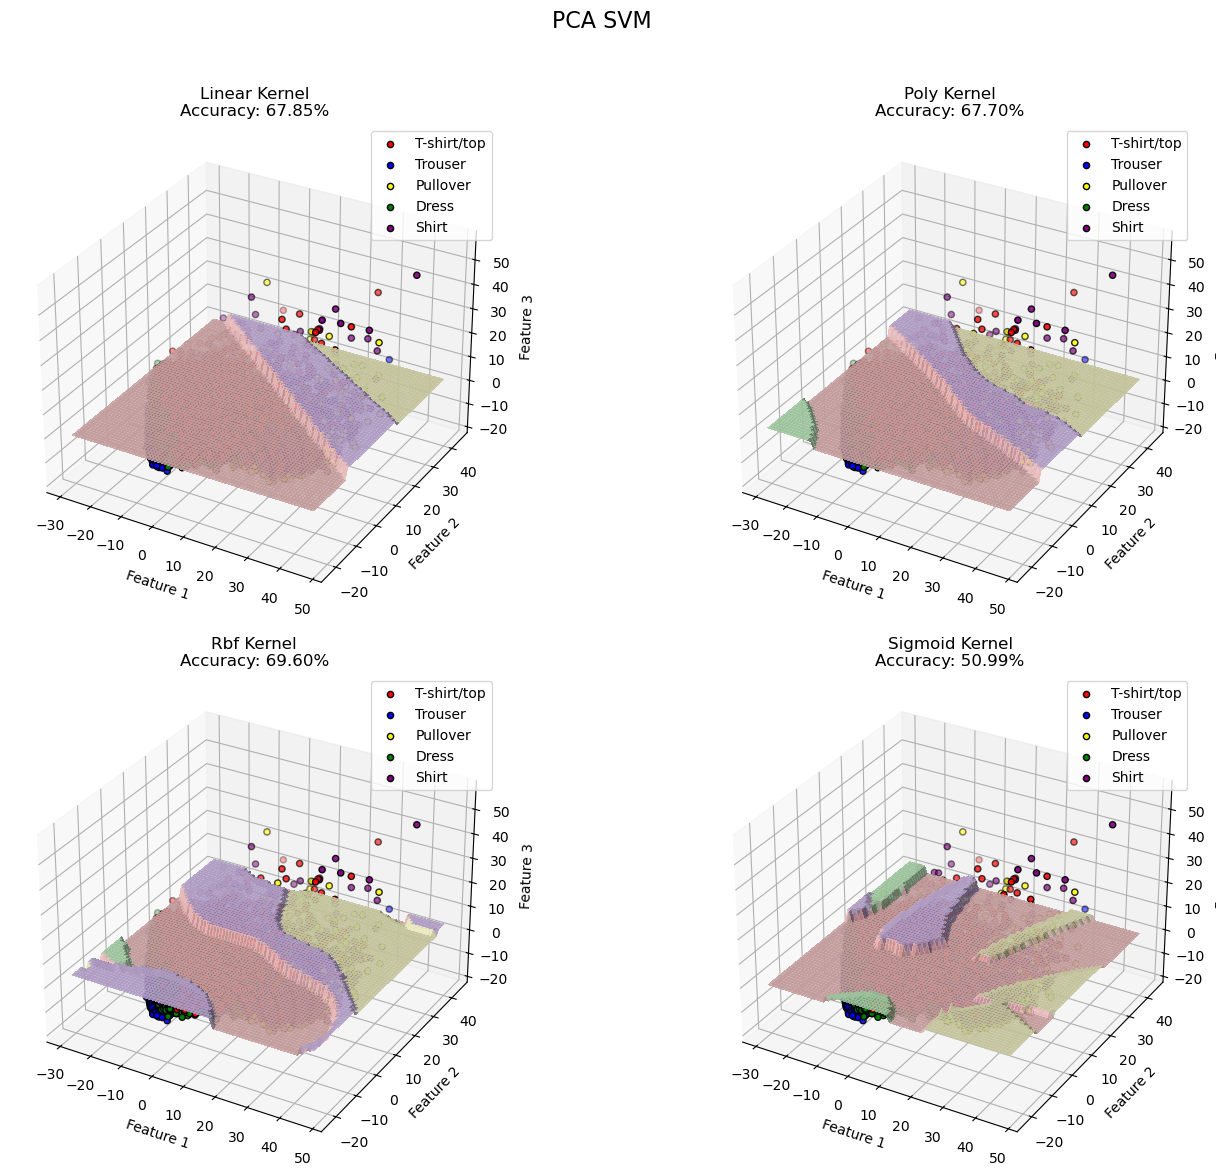

In [76]:
print("Support Vector Machines using PCA data:")
visualize_svm_pca(svms_pca, train_data_pca[:, :3], train_labels, "PCA SVM")


Support Vector Machings using LDA data:


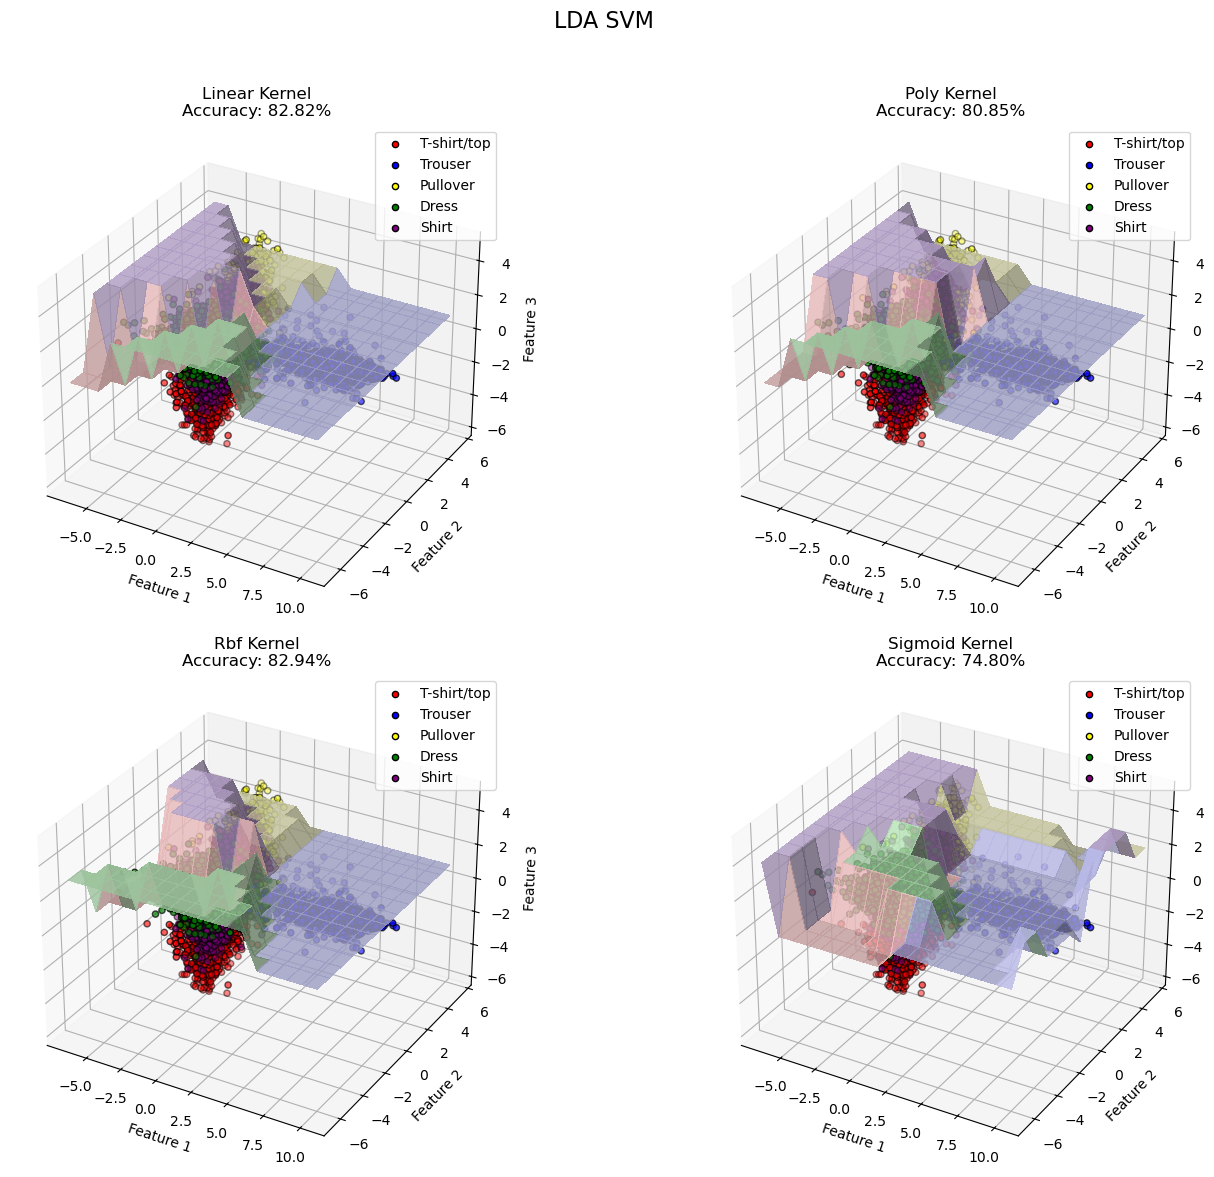

In [77]:
print("Support Vector Machings using LDA data:")
visualize_svm_lda(svms_lda, train_data_lda[:, :3], train_labels, "LDA SVM")
